In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from utils import *
from analise_descritiva import *
from imputacao import *
from limpeza import *
from outliers import *
from visualizacoes import *

In [2]:
# Carregar os dados brutos
dados_brutos, metadados, variaveis = dados(r"data\in\dados_brutos.xlsx")

In [ ]:
# Primeira análise descritiva e conjunto de visualizações
describe_bruto = analise_descritiva(dados_brutos, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(dados_brutos)

# Tenho que arrumar o boxplot_estatisticas, claramente
# dados_brutos_pivot = pivot(dados_brutos, metadados=metadados, variaveis=variaveis)
# boxplot_estatisticas(dados_brutos_pivot)

In [5]:
# Dados brutos prontos
dados_prontos, metadados, variaveis = prep_brutos(dados_brutos)

In [ ]:
describe_pronto = analise_descritiva(dados_prontos, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(dados_prontos)

In [6]:
# Dados limpos
dados_limpos, metadados, variaveis = limpeza(dados_prontos, metadados=metadados, variaveis=variaveis)

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\dados_limpos20260414_151526.xlsx


In [ ]:
describe_limpo = analise_descritiva(dados_limpos, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(dados_limpos)

In [7]:
# Outliers

## Z-Score
remocao_z_score = remove_outliers(dados_limpos, variaveis=variaveis, method='zscore')

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\outliers_removed_zscore20260414_151537.xlsx


c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['149.3' '192.2' '4.0' '46.0' '74.0' '171.0' '1650.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['102.2' '196.5' '1.0' '9.0' '21.0' '92.0' '1200.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in 

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\describe20260414_151630.xlsx
Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\matrix_msno_20260414_151630.png


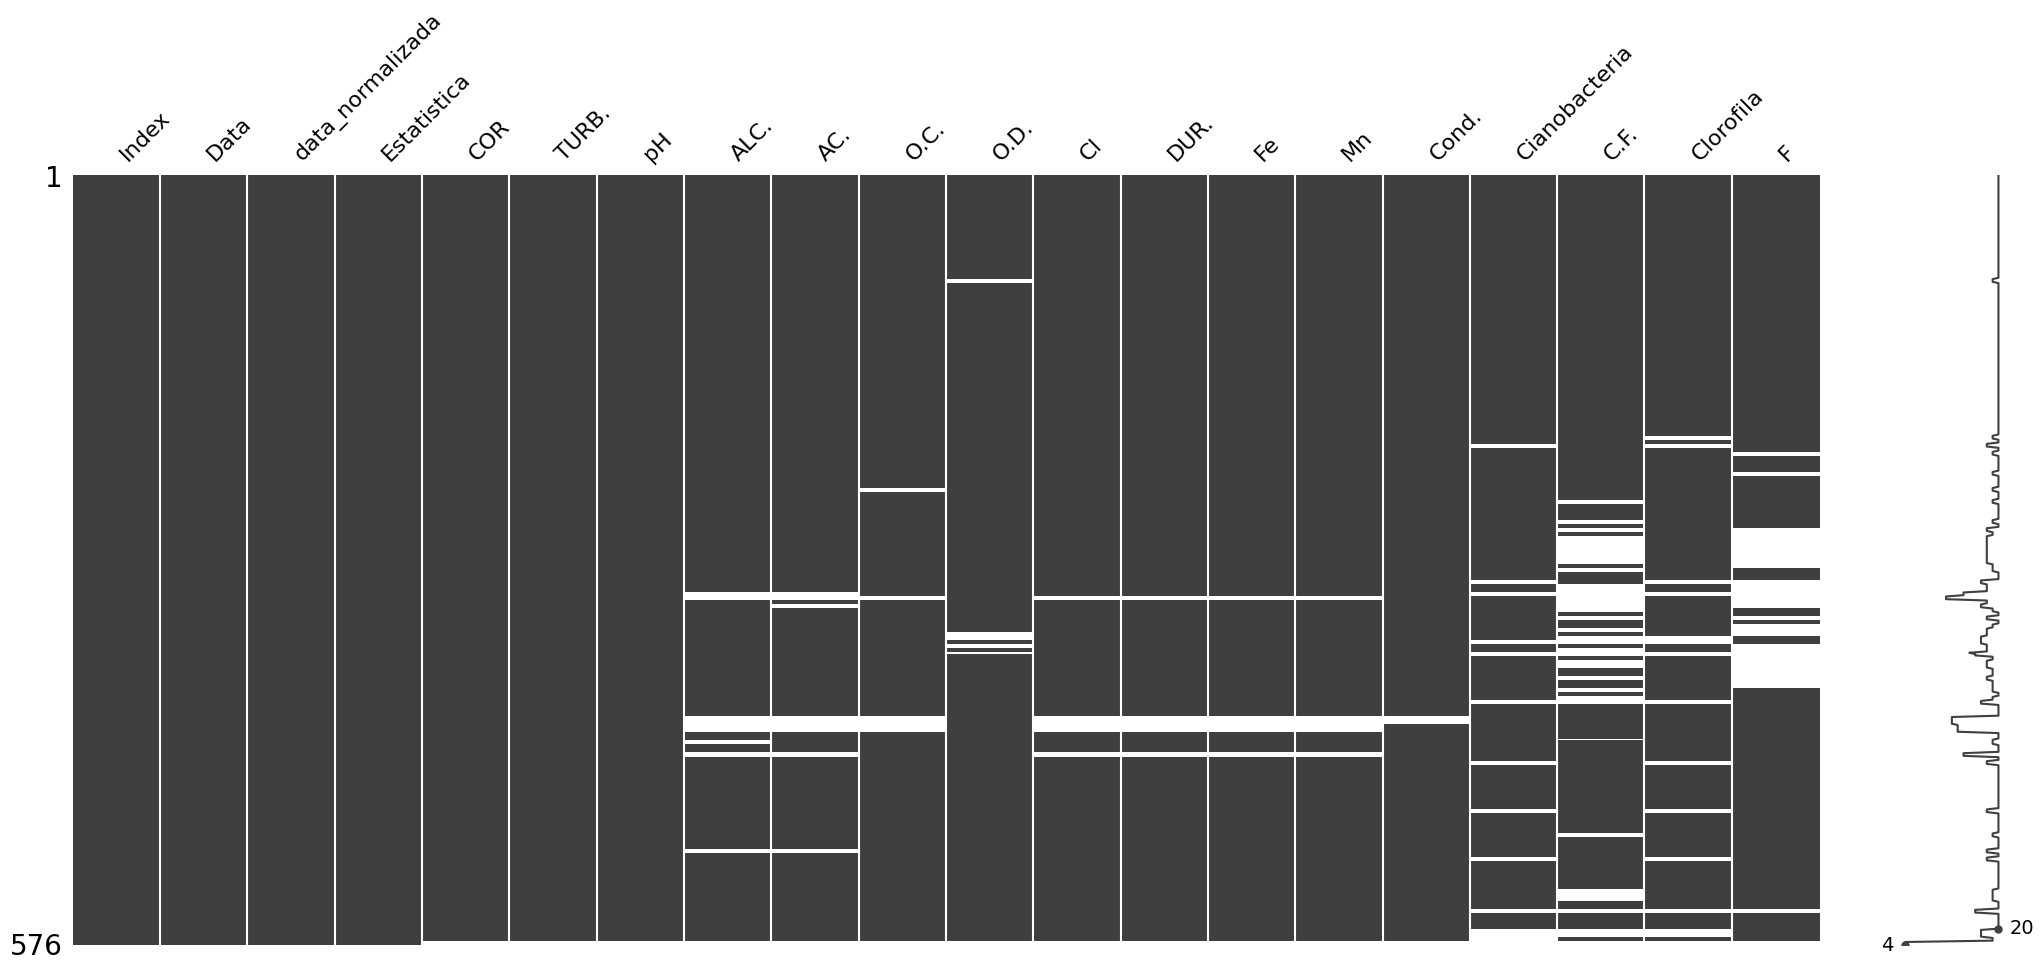

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\bar_msno_20260414_151631.png


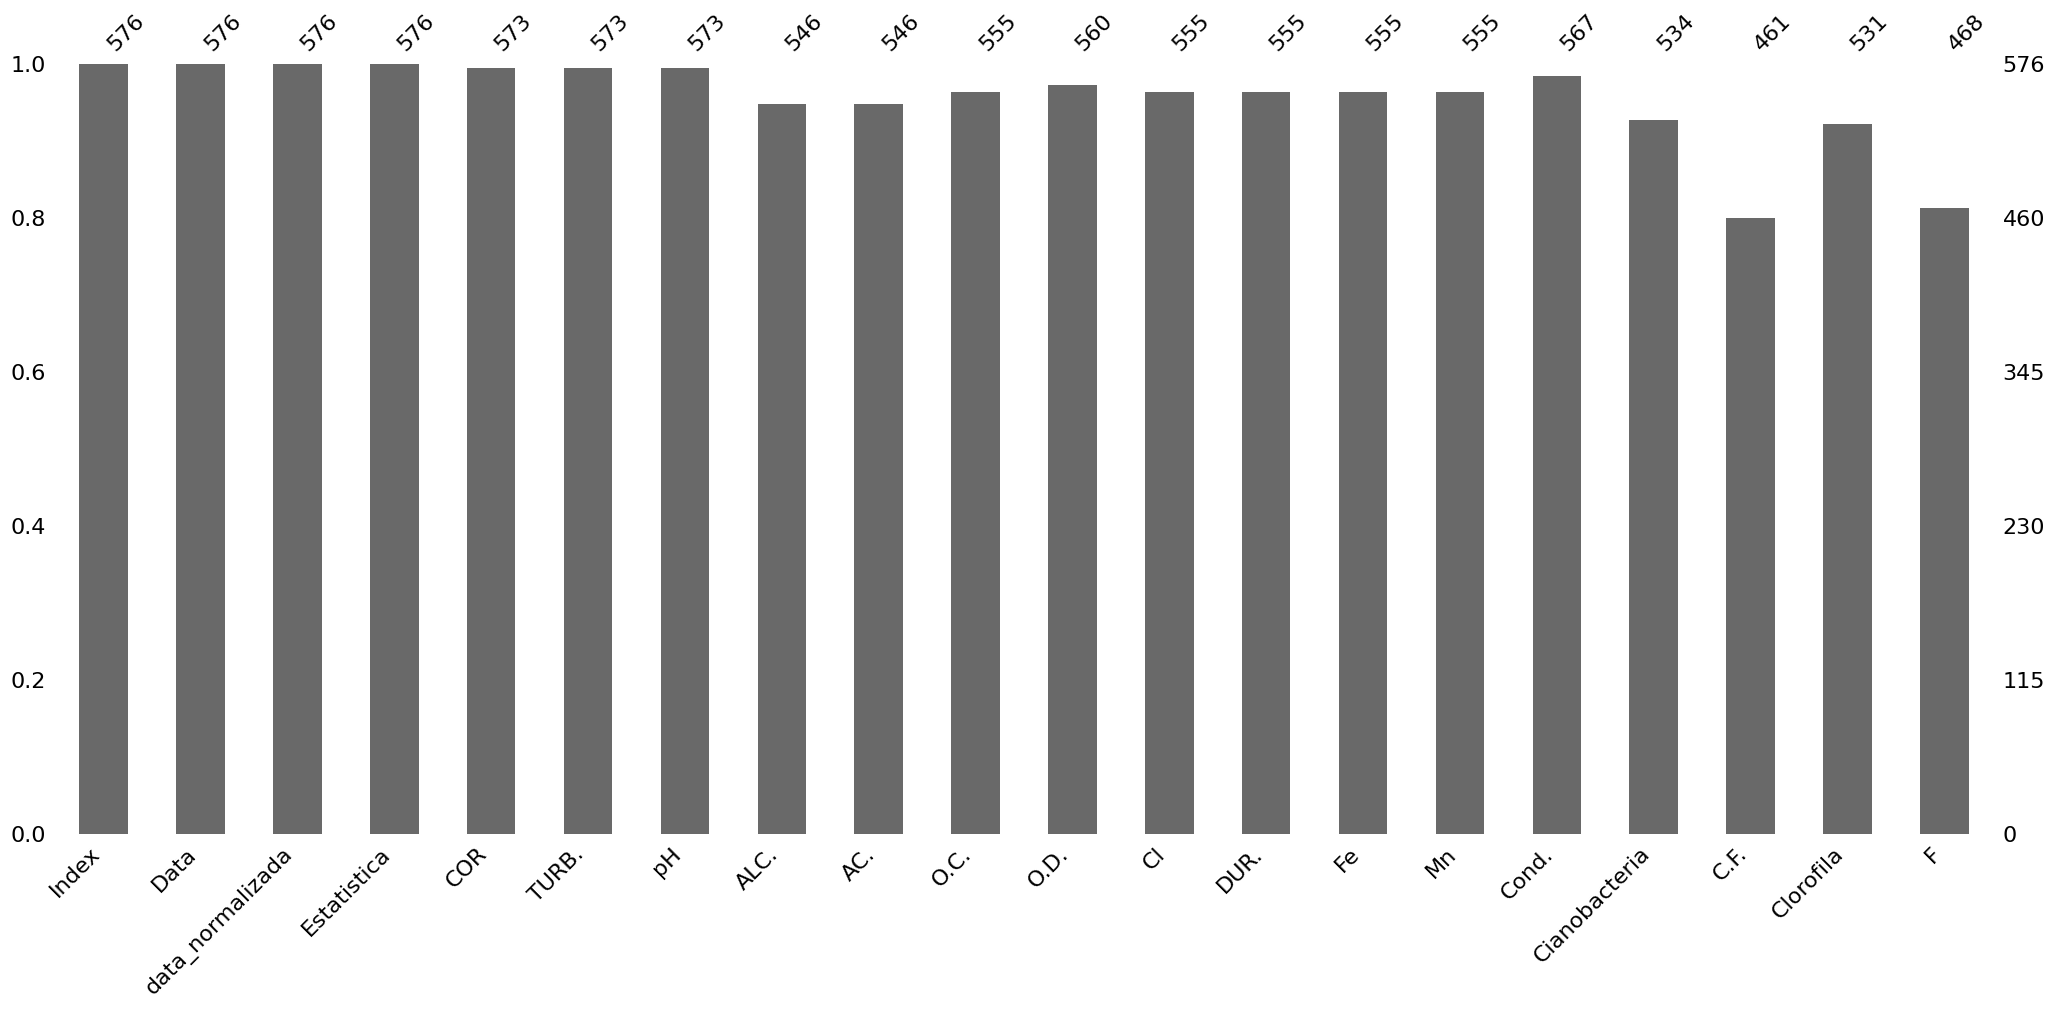

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\heatmap_msno_20260414_151632.png


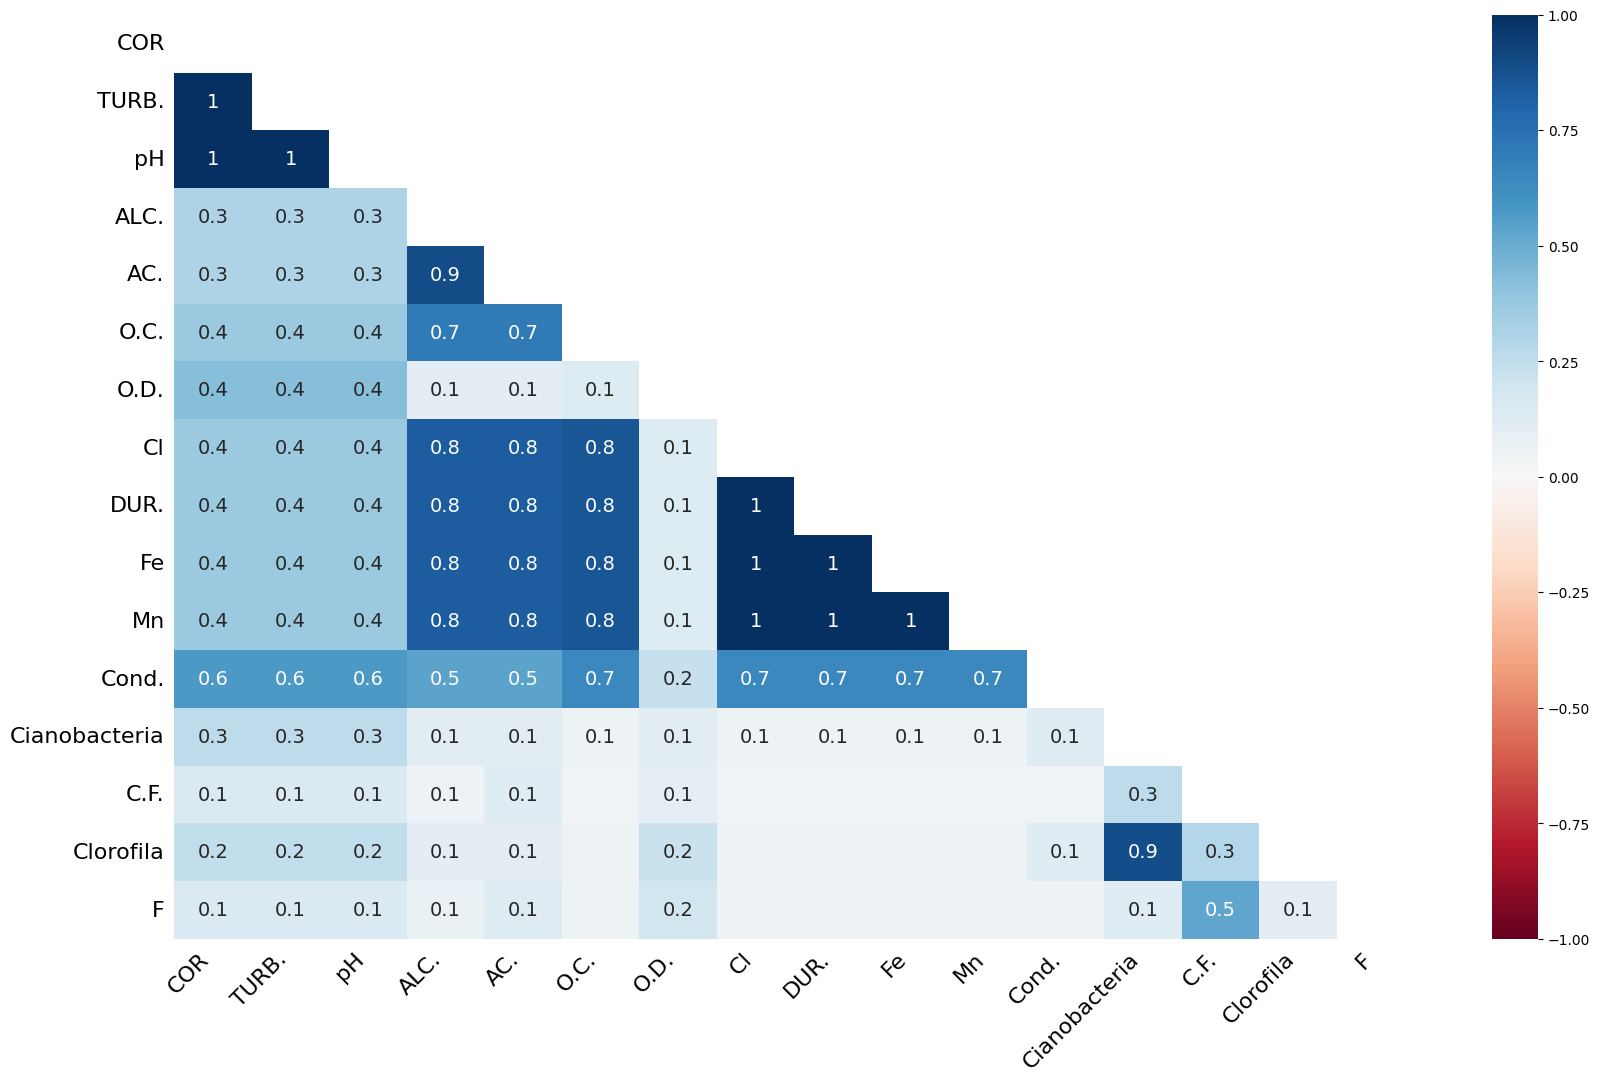

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\dendogram_msno_20260414_151632.png


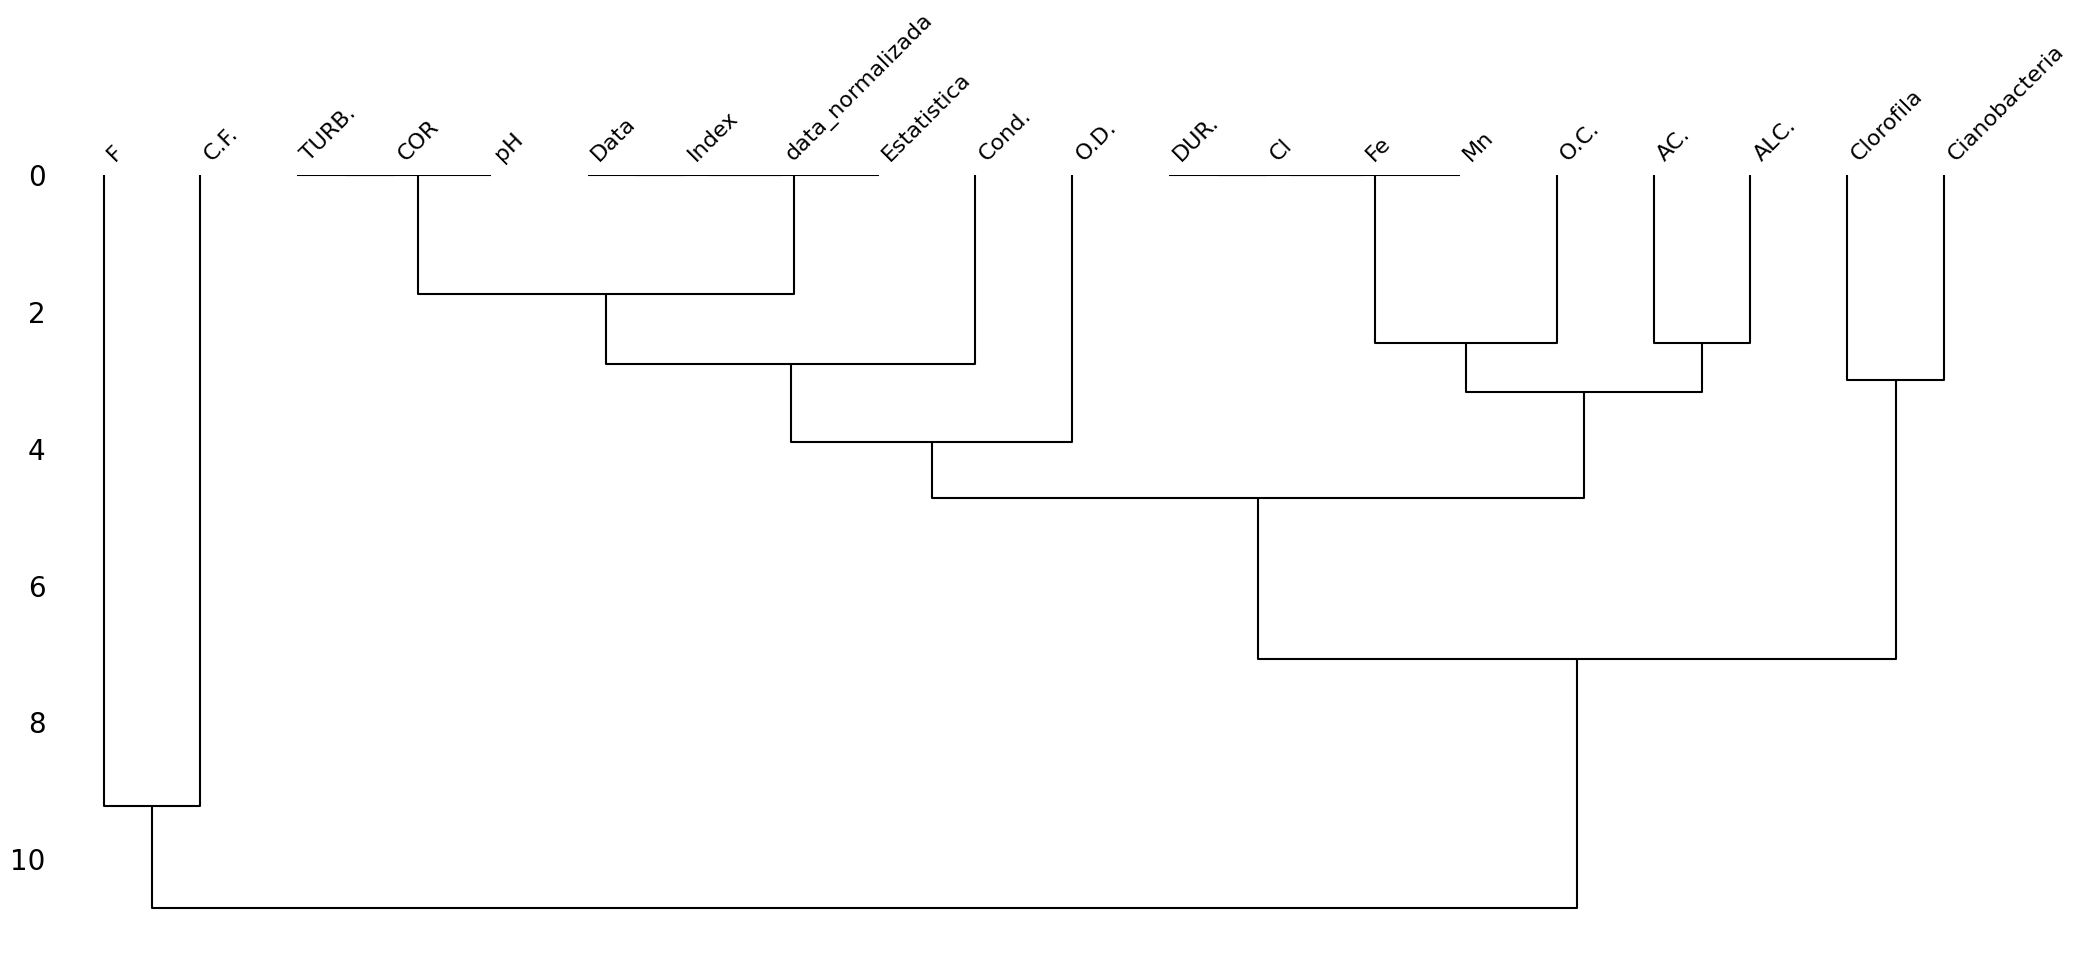

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_ano_20260414_151633.png


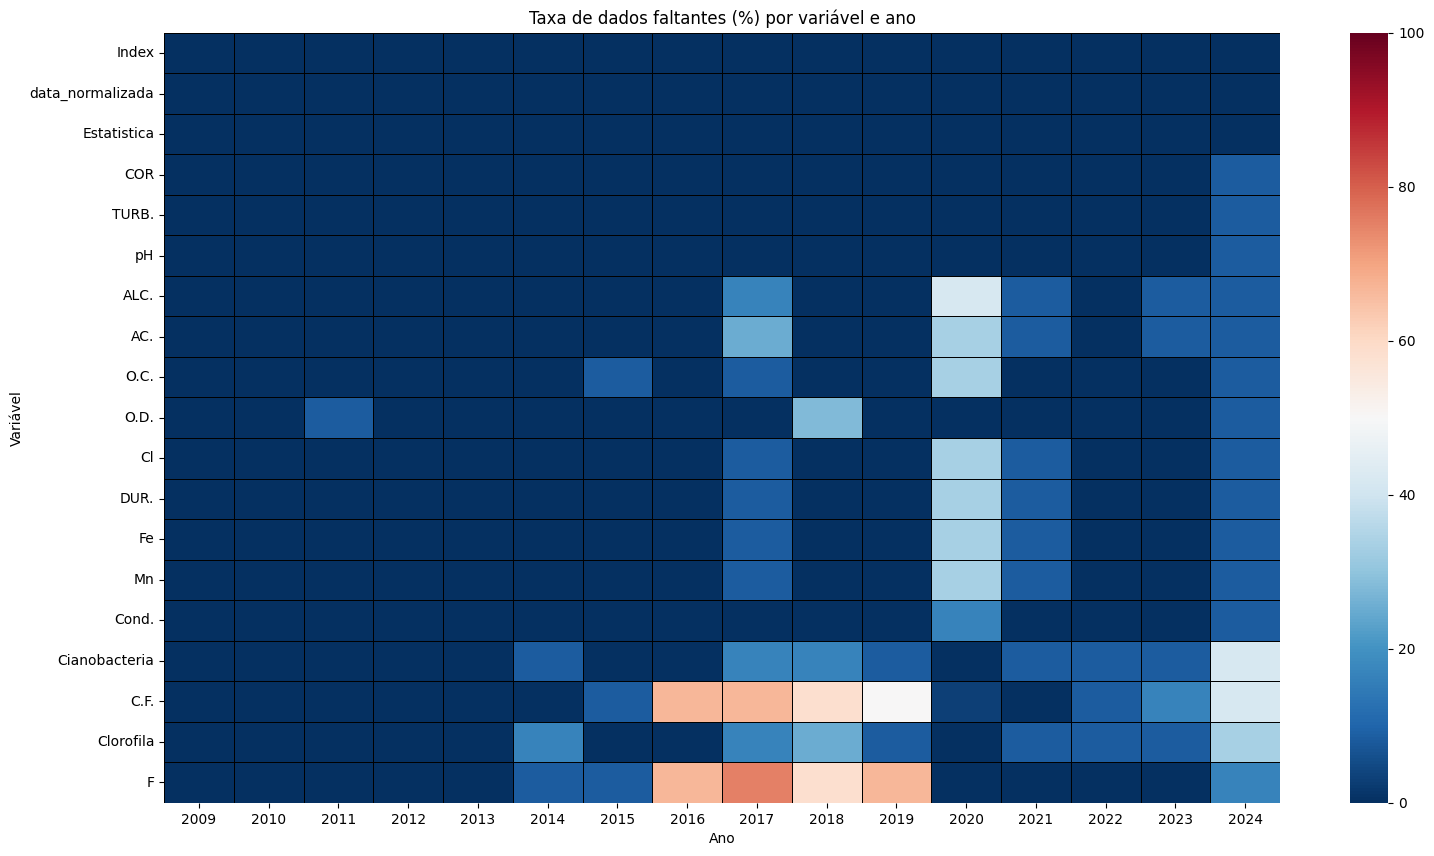

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_mes_20260414_151633.png


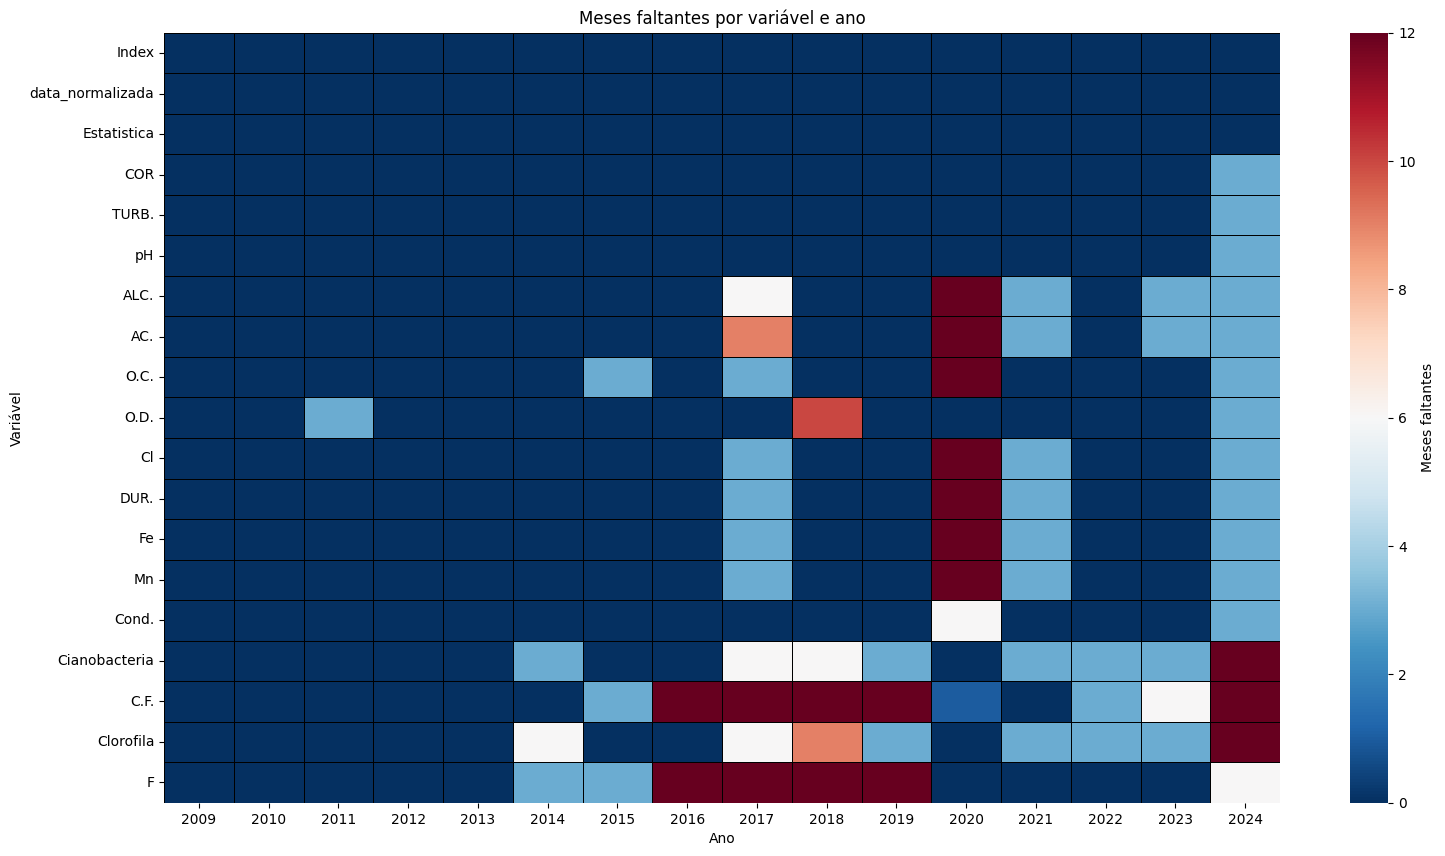

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\boxplot_tudo_20260414_151635.png


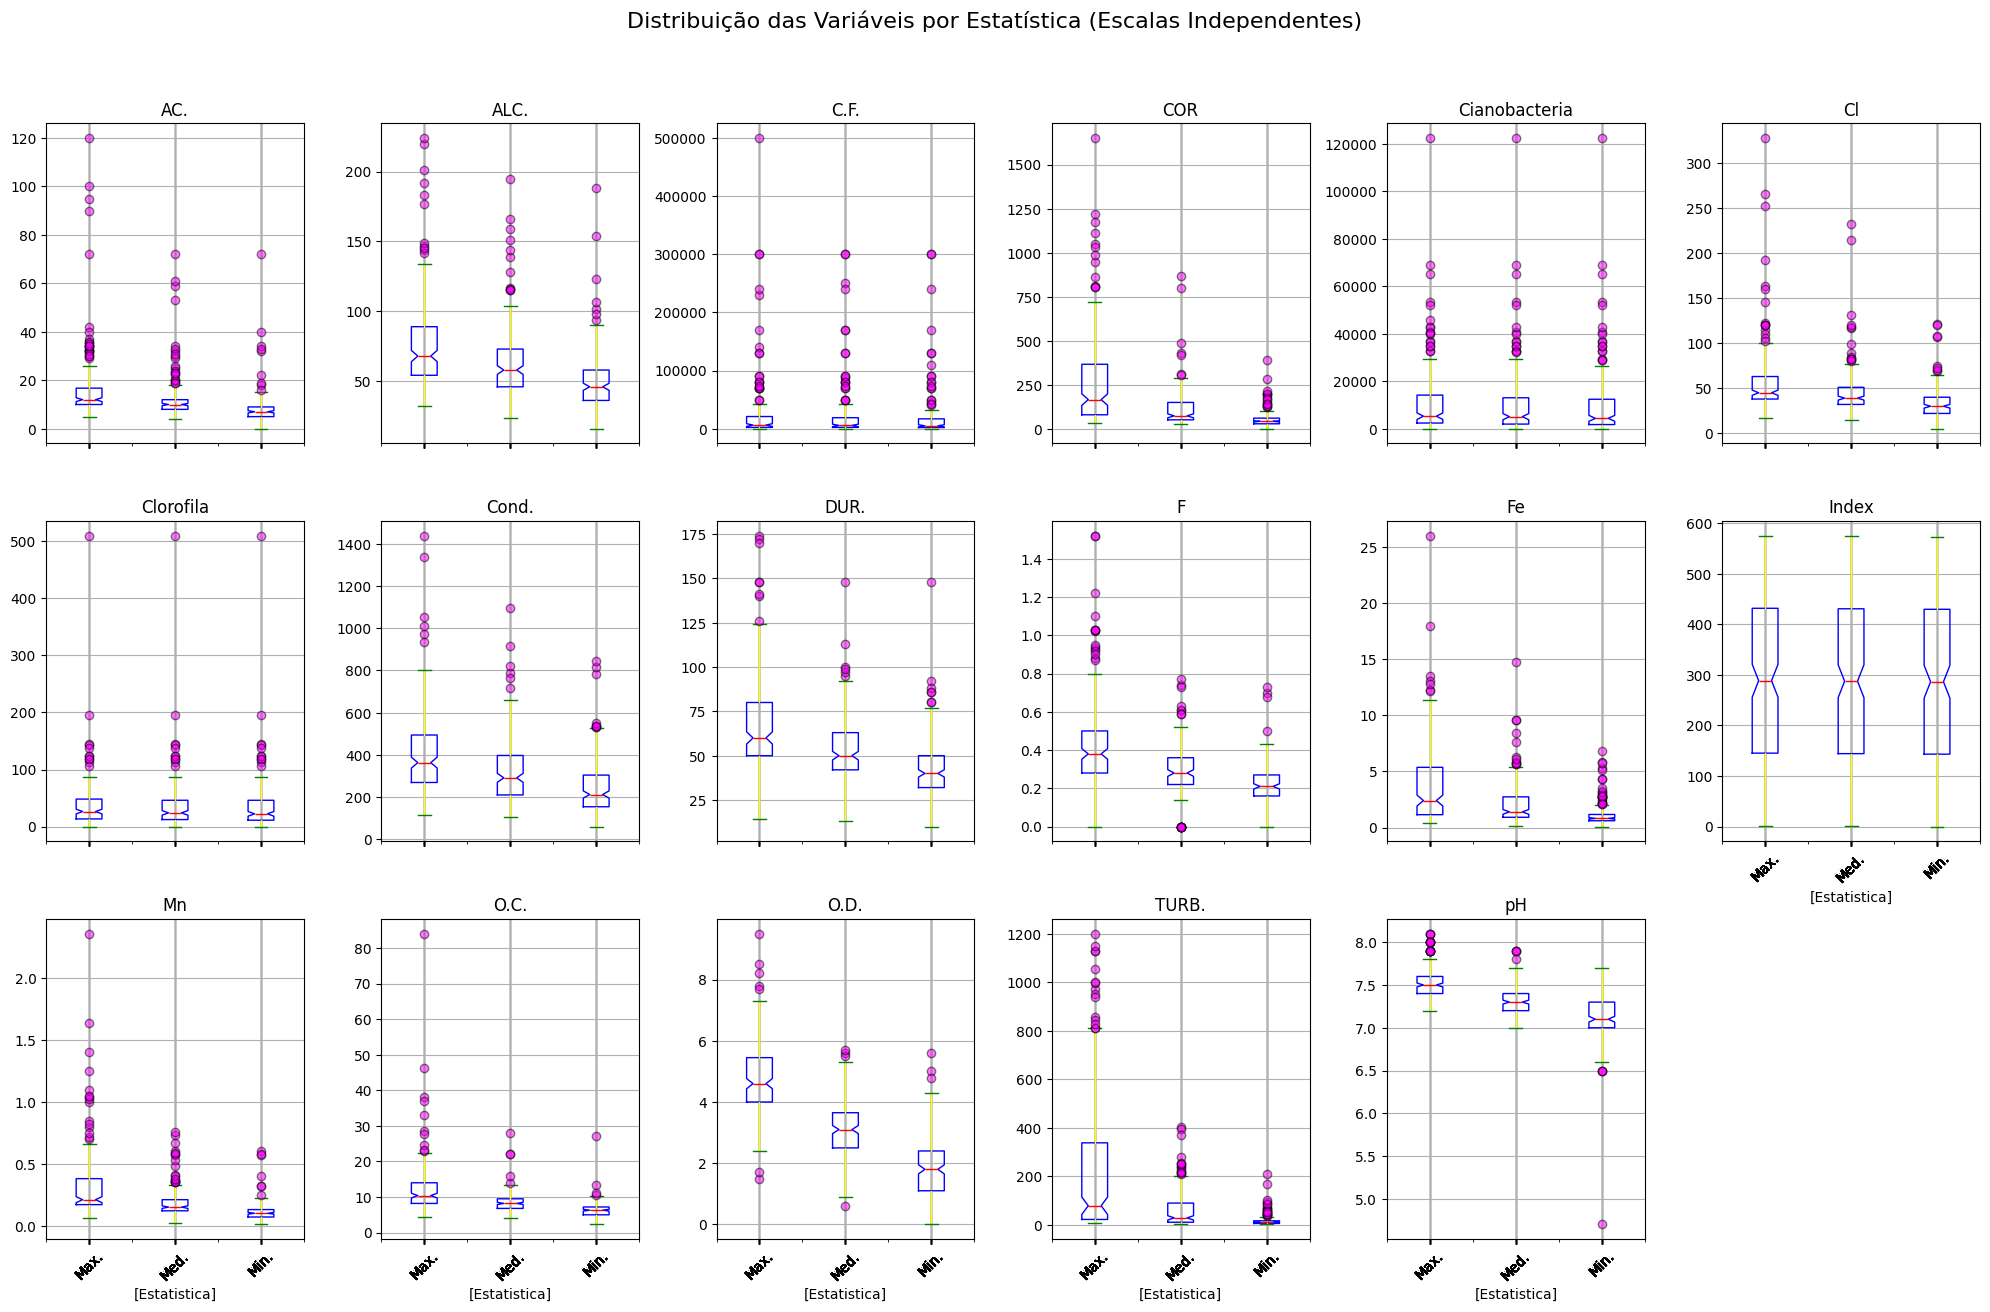

In [8]:
describe_z_score = analise_descritiva(remocao_z_score, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(remocao_z_score)

In [9]:
## IQR
remocao_iqr = remove_outliers(dados_limpos, variaveis=variaveis, method='iqr')

Outliers detectados por IQR (Tukey):
COR: 55 outliers (limites: -141.500 a 358.500)
TURB.: 75 outliers (limites: -115.500 a 216.500)
pH: 21 outliers (limites: 6.750 a 7.950)
ALC.: 28 outliers (limites: -3.625 a 123.375)
AC.: 51 outliers (limites: -2.000 a 22.000)
O.C.: 37 outliers (limites: 0.450 a 16.050)
O.D.: 5 outliers (limites: -1.200 a 7.600)
Cl: 38 outliers (limites: -1.500 a 82.500)
DUR.: 23 outliers (limites: 4.000 a 100.000)
Fe: 53 outliers (limites: -2.163 a 5.818)
Mn: 60 outliers (limites: -0.055 a 0.385)
Cond.: 25 outliers (limites: -98.250 a 703.750)
Cianobacteria: 46 outliers (limites: -14886.000 a 30314.000)
C.F.: 57 outliers (limites: -23000.000 a 44200.000)
Clorofila: 33 outliers (limites: -40.055 a 99.505)
F: 26 outliers (limites: -0.076 a 0.654)

Total de outliers (IQR, somando todas as colunas): 633
Total de linhas com pelo menos um outlier (IQR): 269
Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\outliers_removed_iqr20260414_151701.xlsx


In [ ]:
describe_iqr = analise_descritiva(remocao_iqr, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(remocao_iqr)

In [ ]:
## LOF - Repete no Final
remocao_lof = remove_outliers(dados_limpos, variaveis=variaveis, method='lof')

# Só funciona pós imputação: LocalOutlierFactor does not accept missing values encoded as NaN natively. 
# For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor 
# which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, 
# for instance by using an imputer transformer in a pipeline or drop samples with missing values. 
# See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page:
#  https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

ValueError: Input X contains NaN.
LocalOutlierFactor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
describe_lof = analise_descritiva(remocao_lof, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(remocao_lof)

In [11]:
# Imputação

## Média
imput_media = mean_imput(dados_limpos, variaveis=variaveis)

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\imput_mean20260414_151910.xlsx


c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['149.25305410122166' '191.74758909954386' '4.00000000000000'
 '46.00000000000000' '75.00000000000000' '171.00000000000000'
 '1650.00000000000000']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['102.21989528795811' '196.00702868139911' '1.00000000000000'
 '9.00000000000000' '21.50000000000000' '95.25000000000000'
 '1200.00000000000000']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dad

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\describe20260414_152017.xlsx
Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\matrix_msno_20260414_152018.png


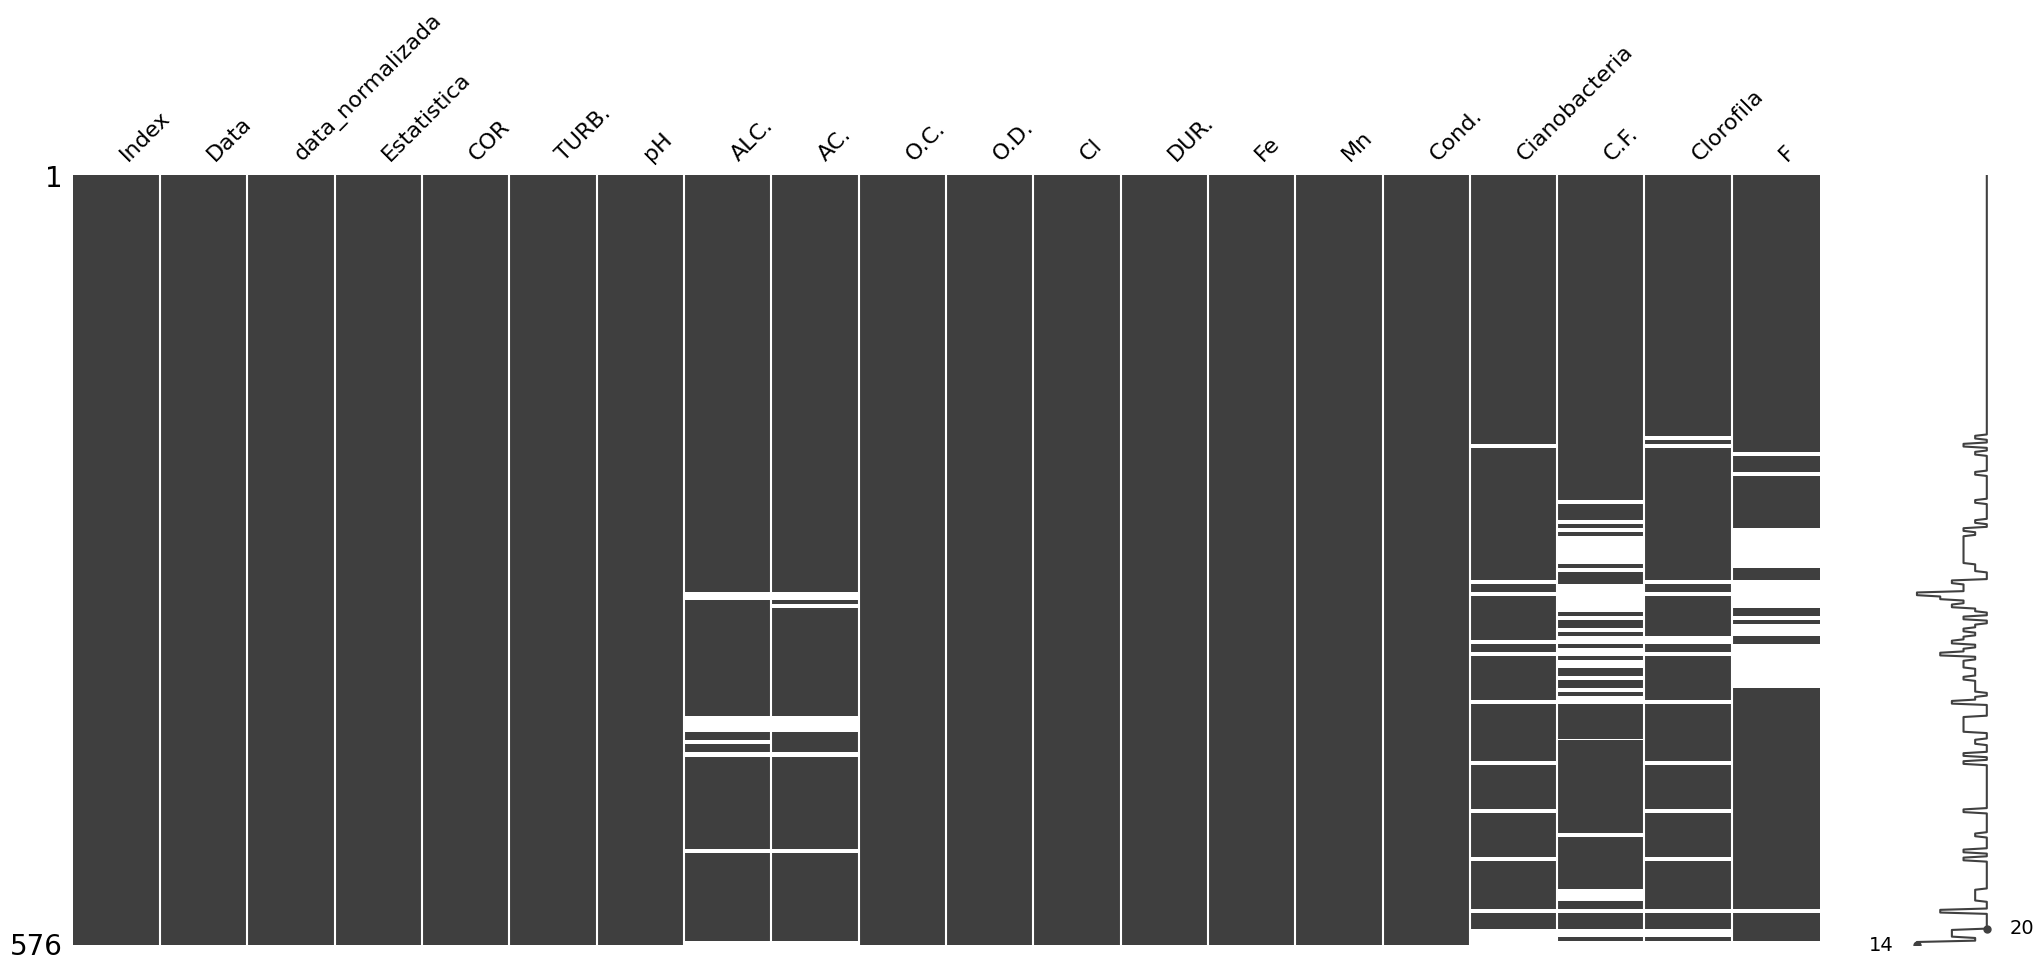

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\bar_msno_20260414_152018.png


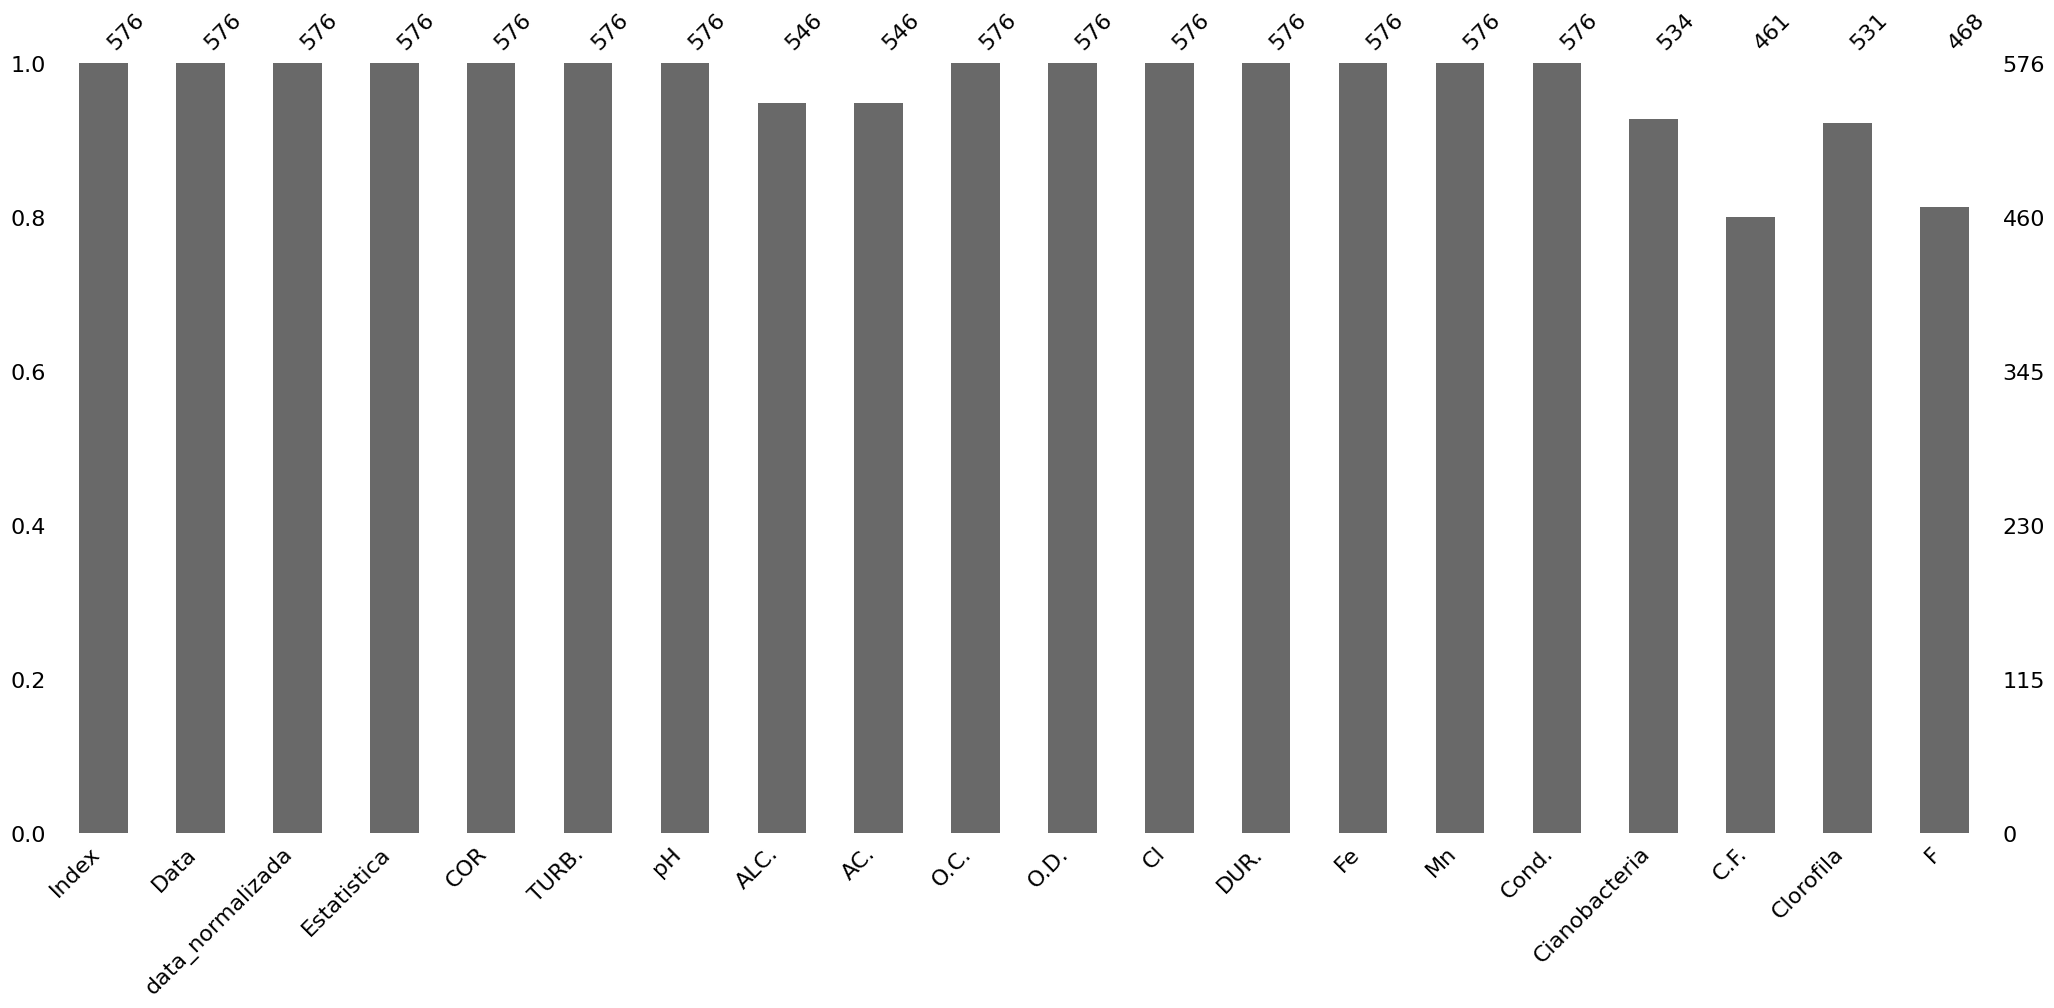

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\heatmap_msno_20260414_152019.png


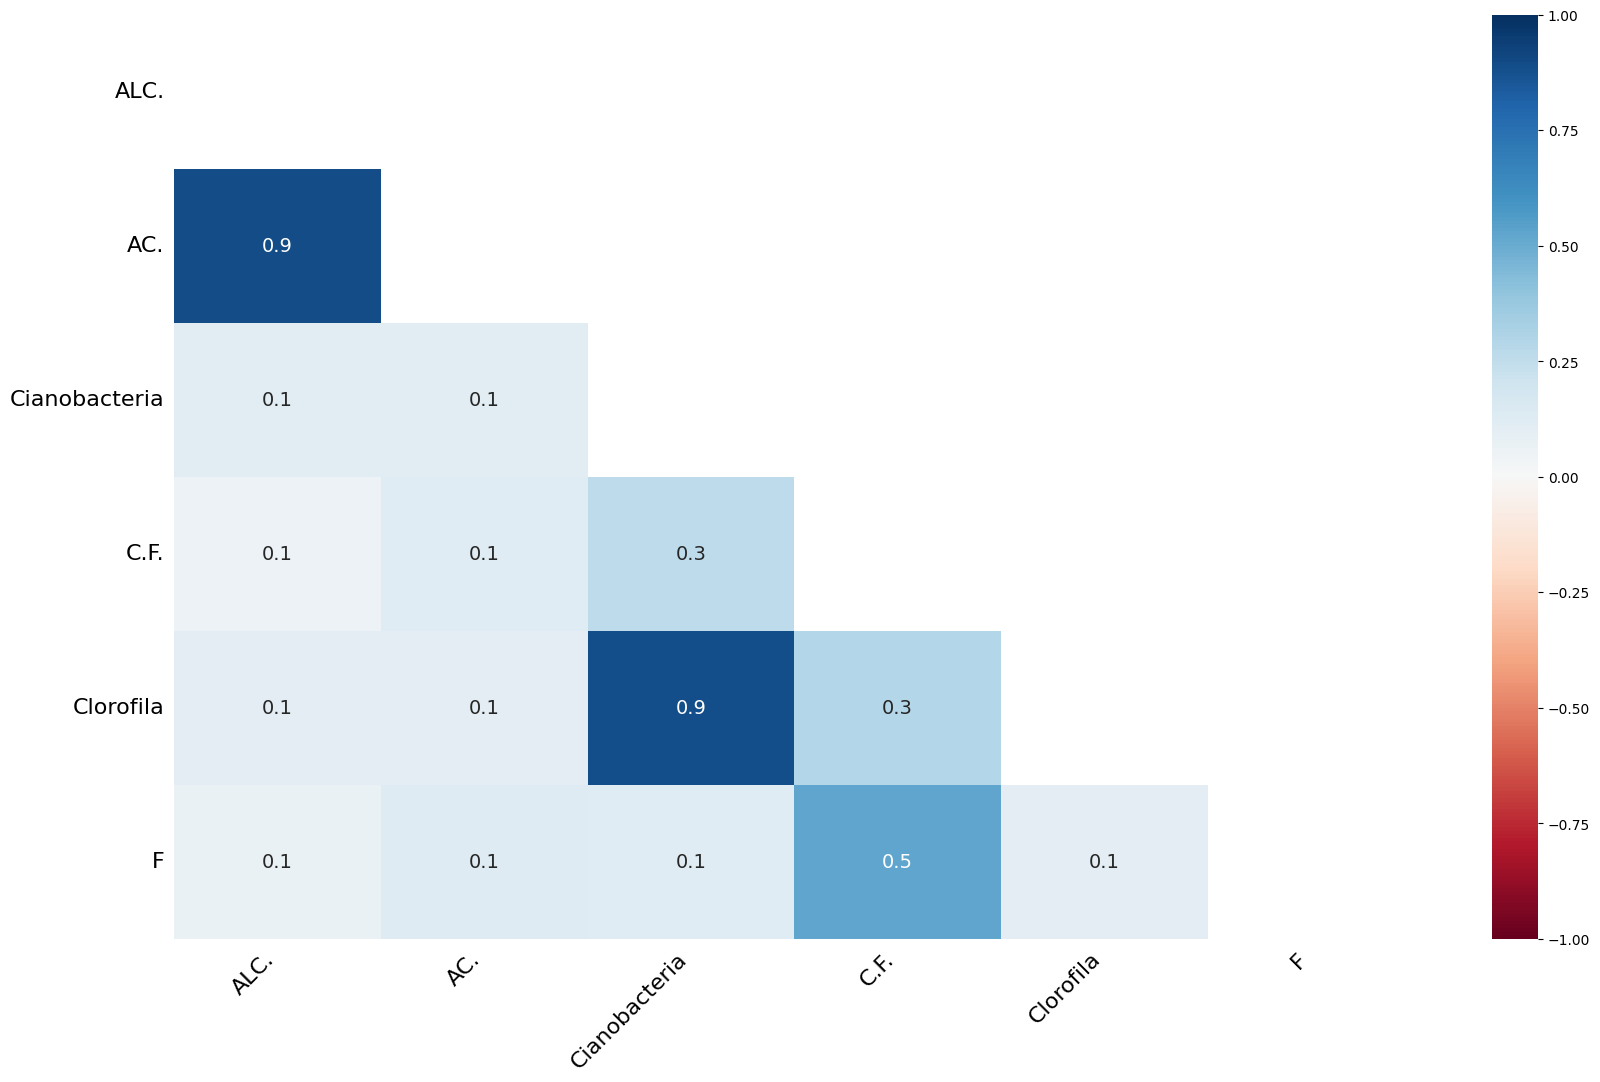

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\dendogram_msno_20260414_152019.png


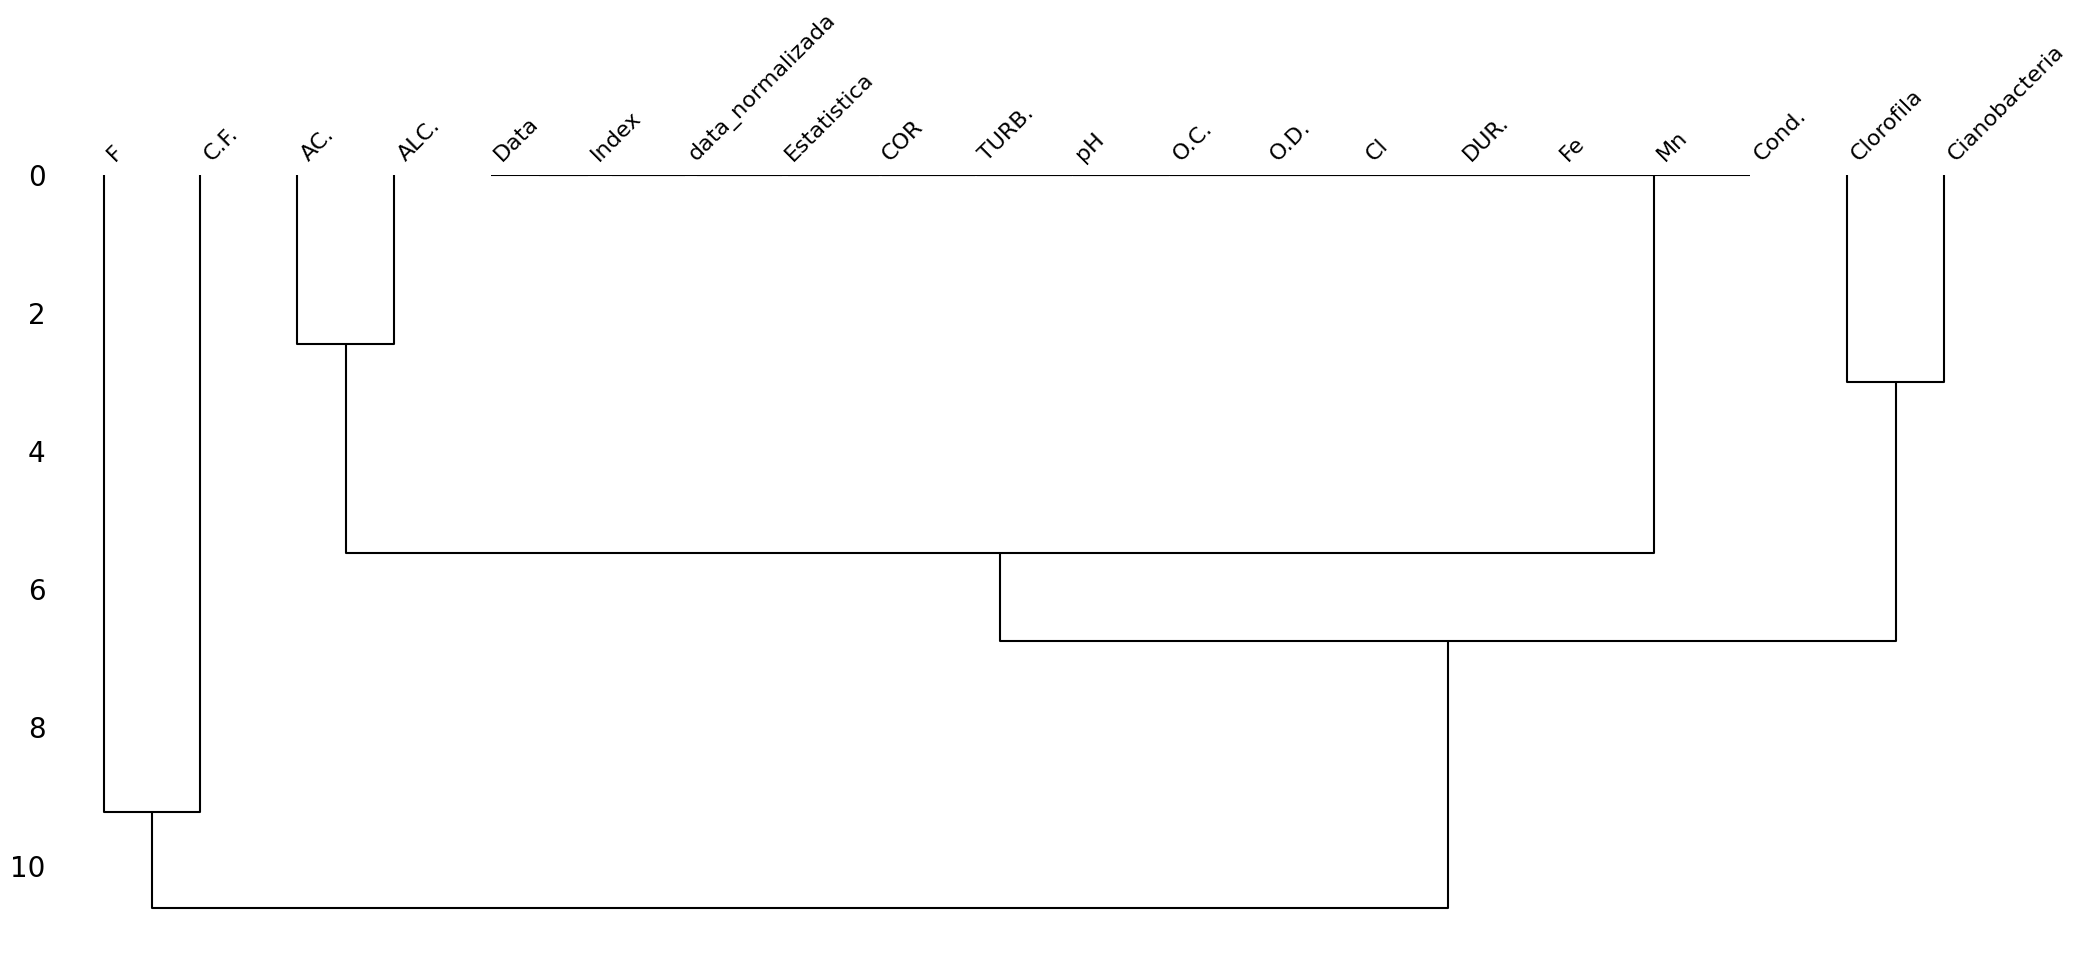

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_ano_20260414_152020.png


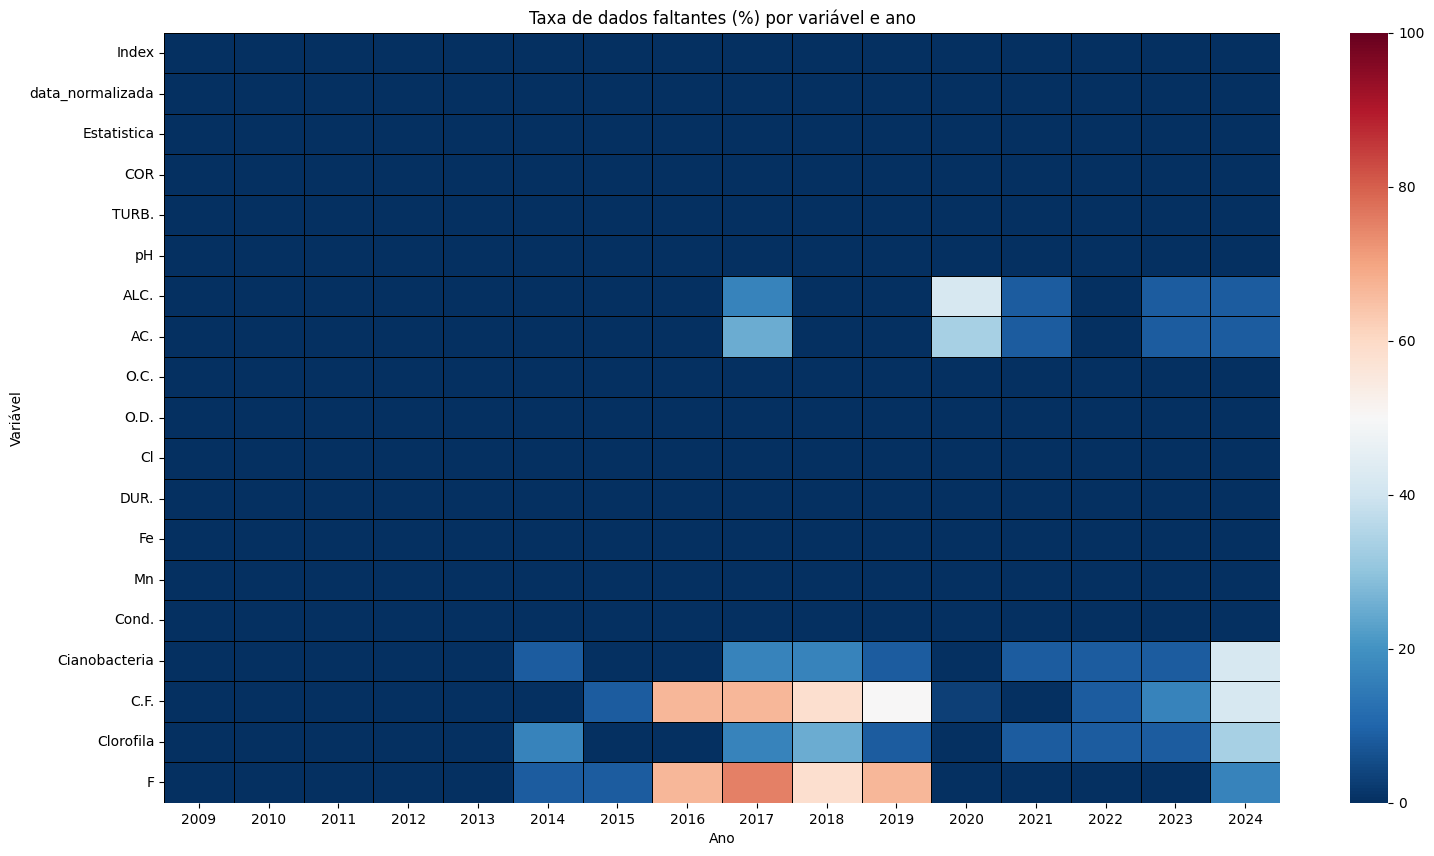

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_mes_20260414_152020.png


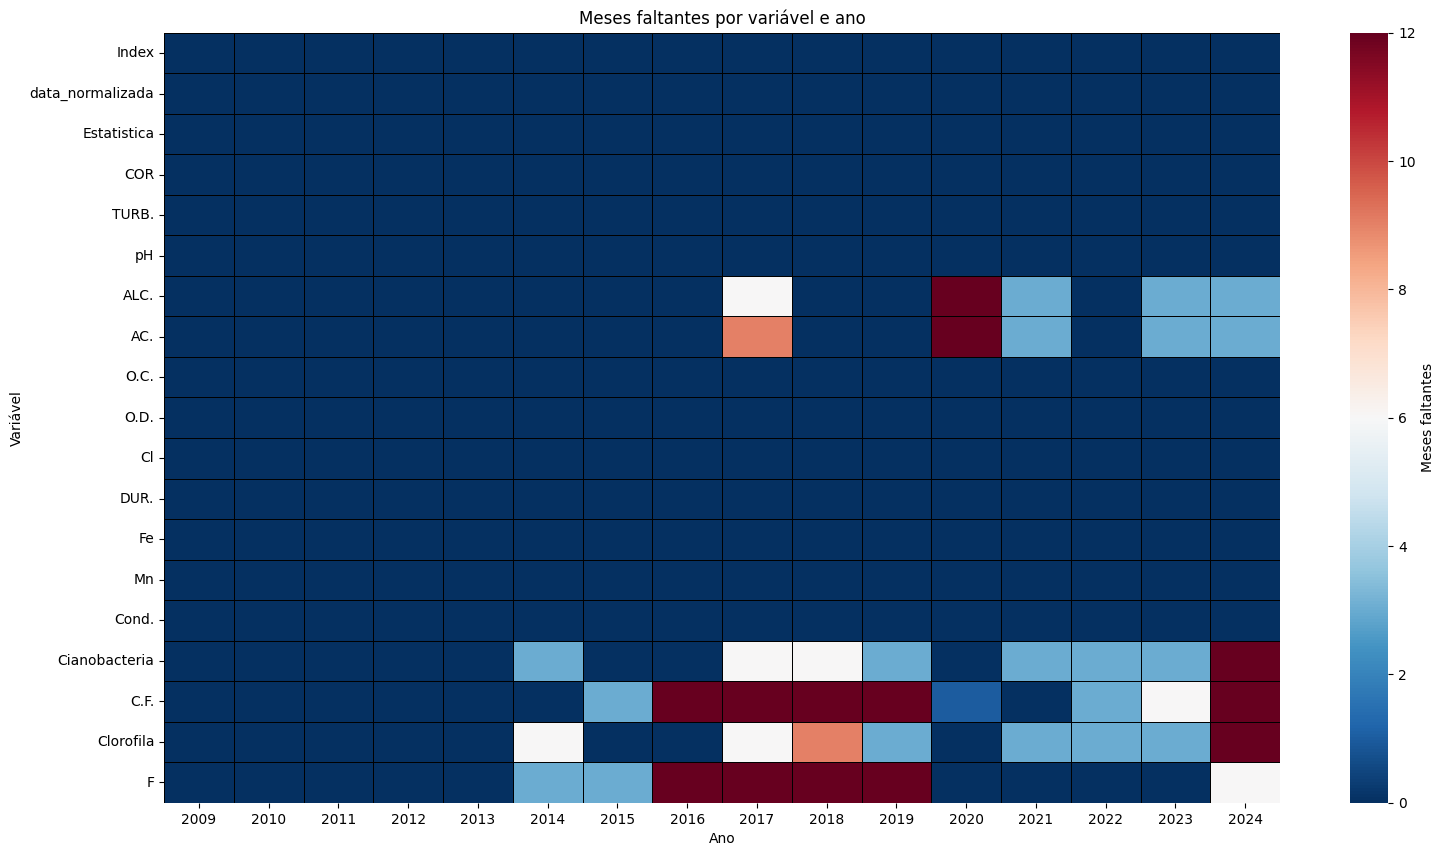

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\boxplot_tudo_20260414_152022.png


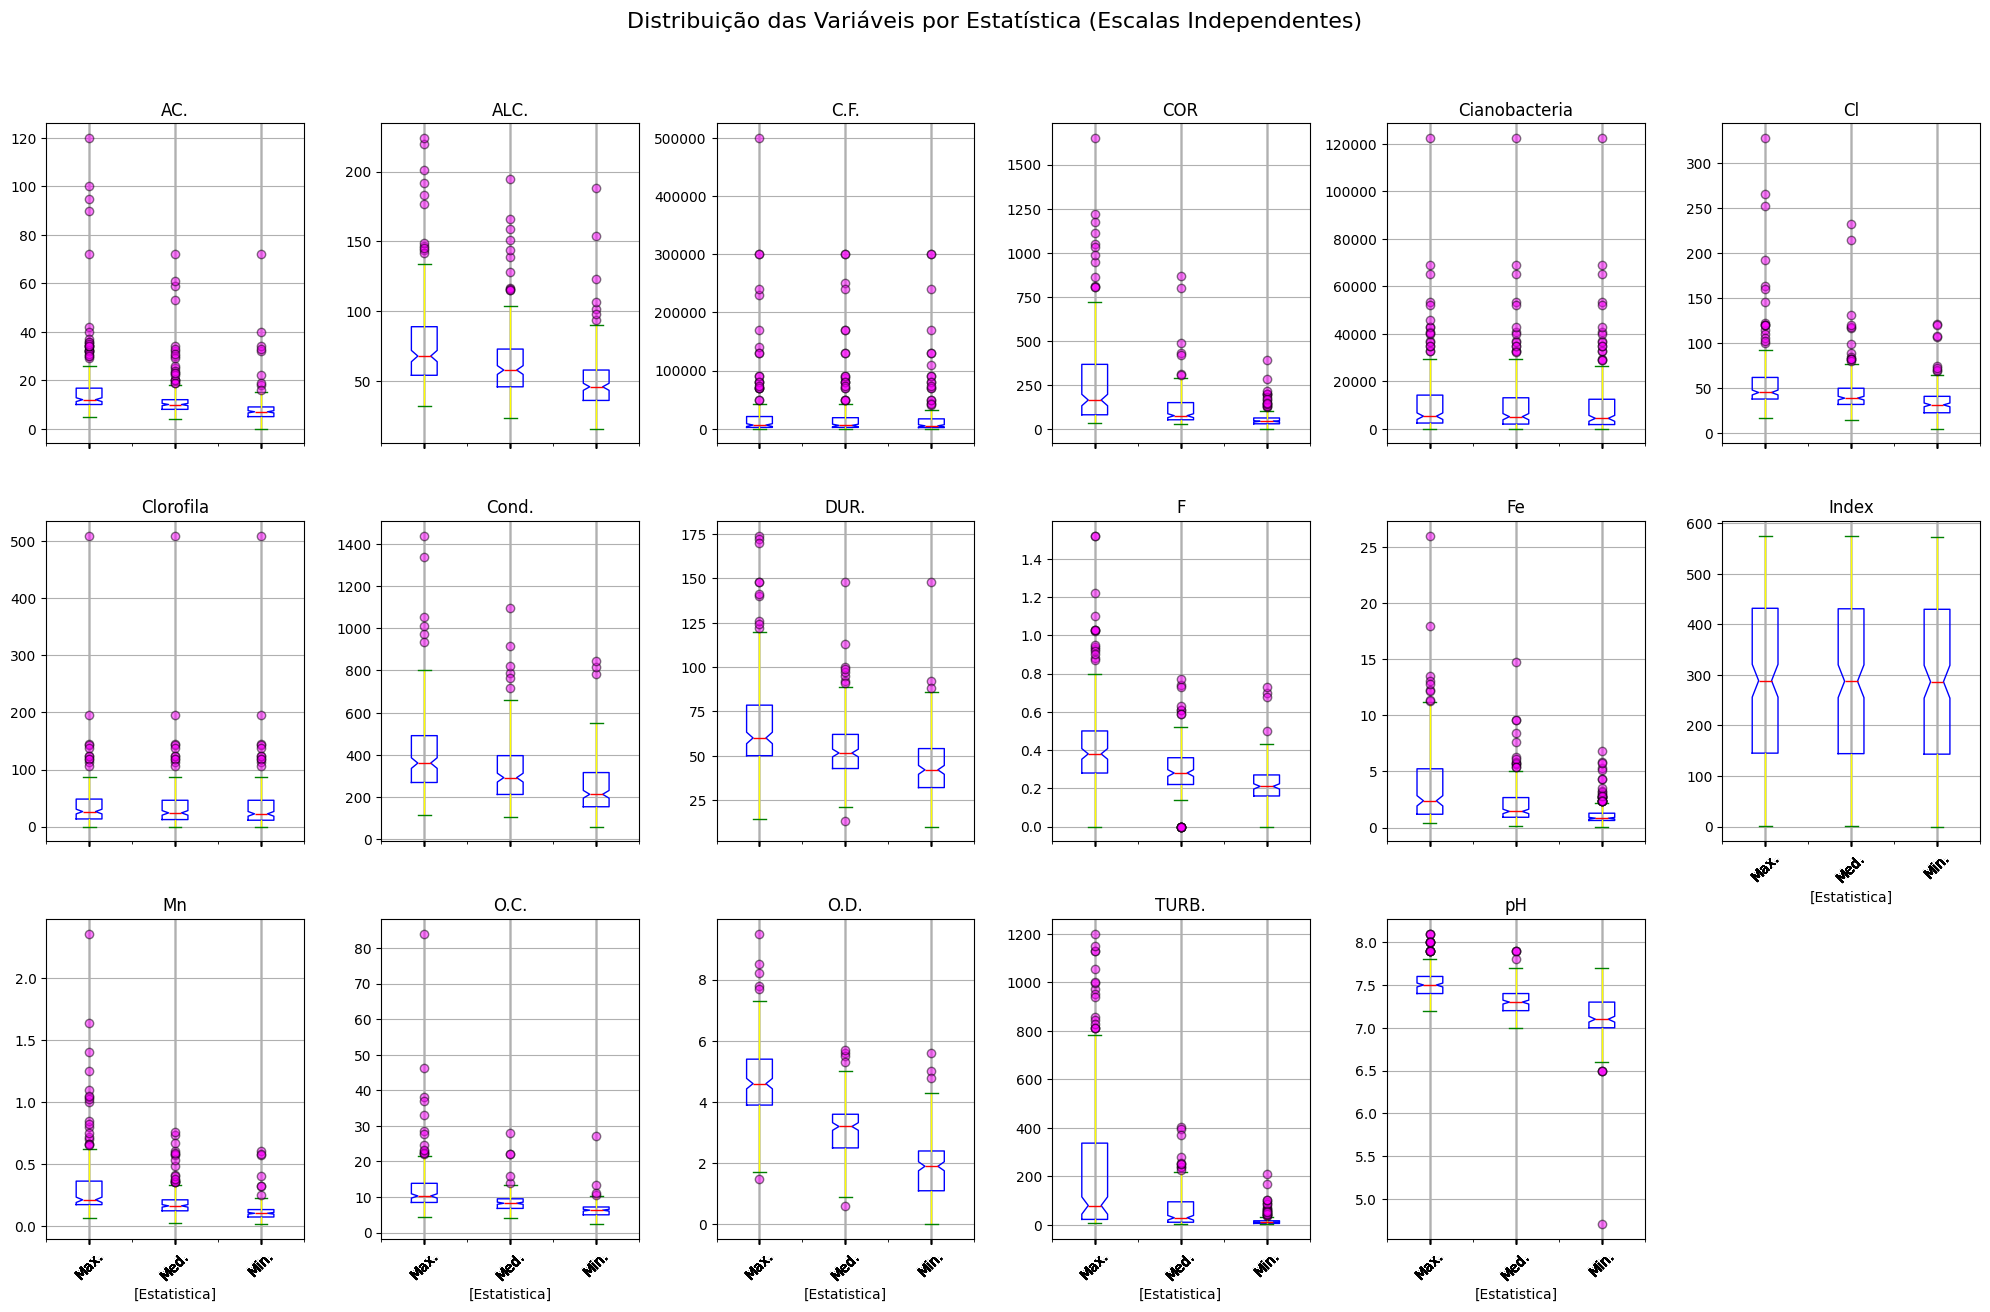

In [12]:
describe_imput_media = analise_descritiva(imput_media, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(imput_media)

In [13]:
## Mediana
imput_mediana = median_imput(dados_limpos, variaveis=variaveis)

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\imput_median20260414_152038.xlsx


c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['148.9' '191.8' '4.0' '46.0' '74.0' '171.0' '1650.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['101.8' '196.1' '1.0' '9.0' '21.0' '92.0' '1200.0']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in 

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\describe20260414_152041.xlsx
Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\matrix_msno_20260414_152041.png


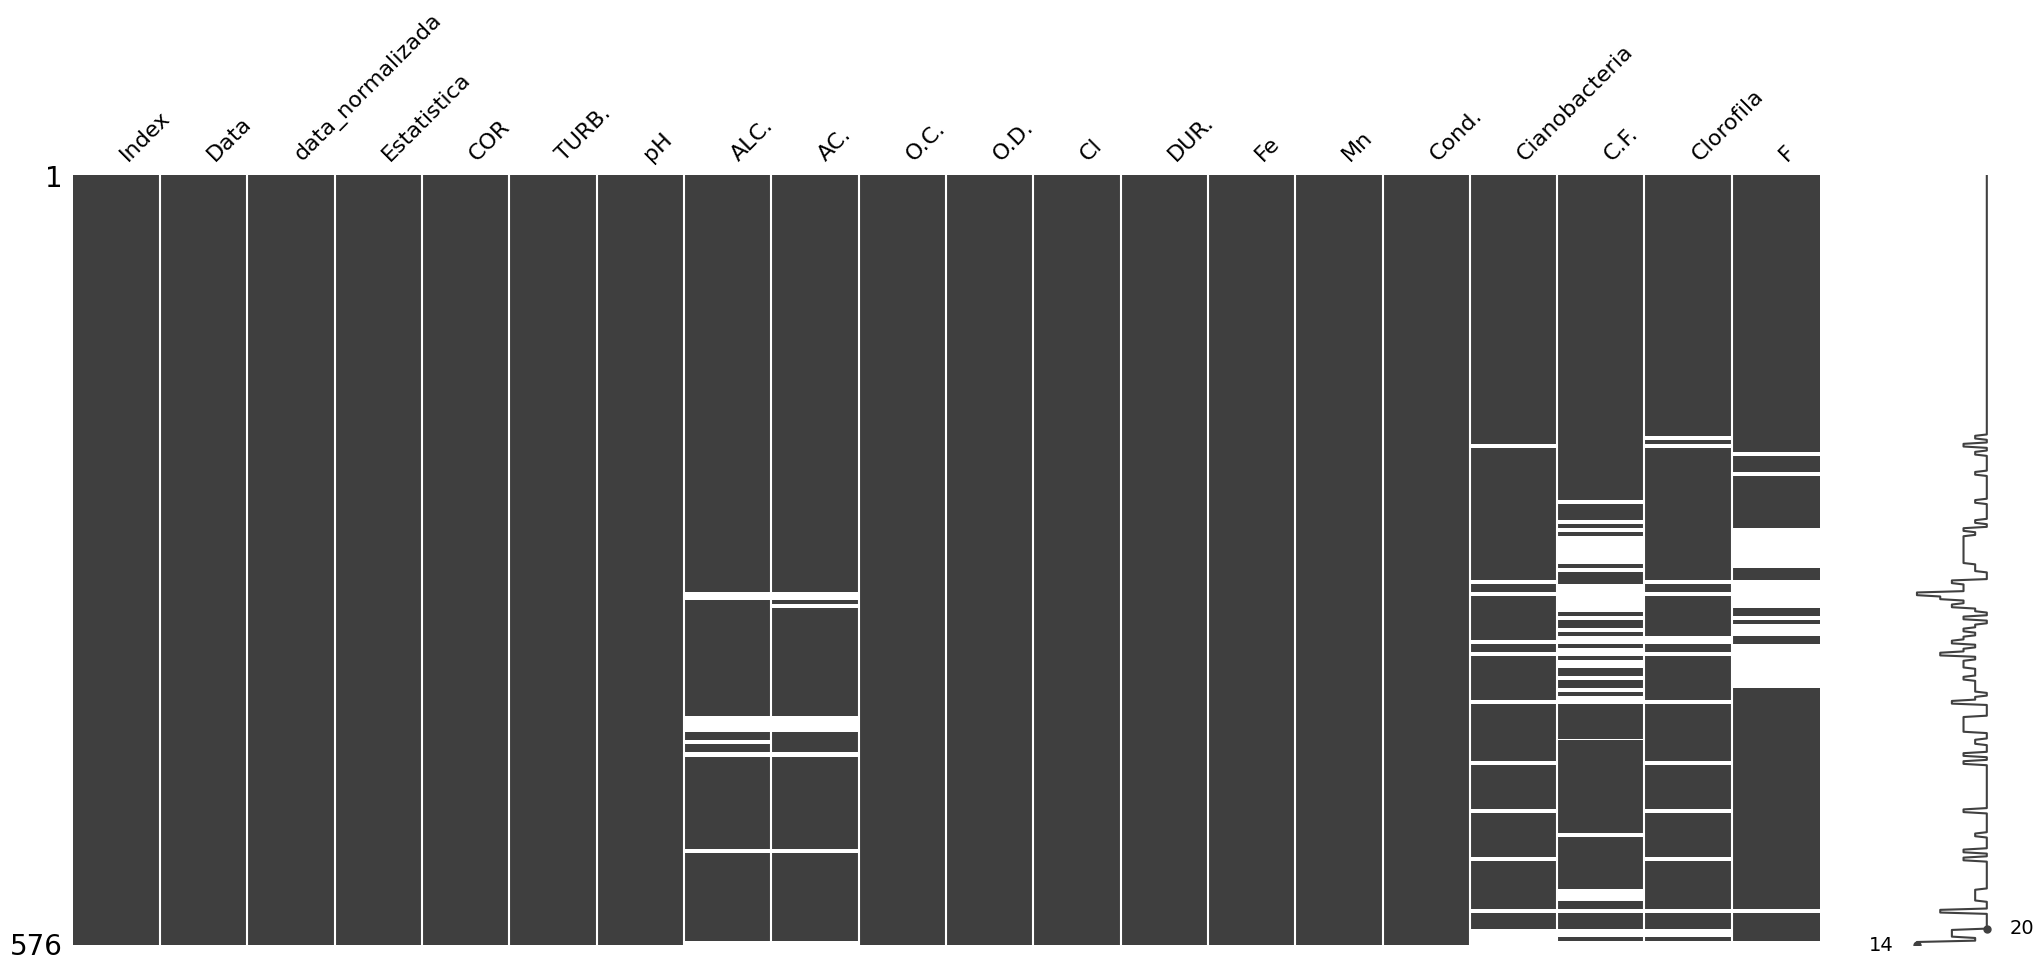

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\bar_msno_20260414_152042.png


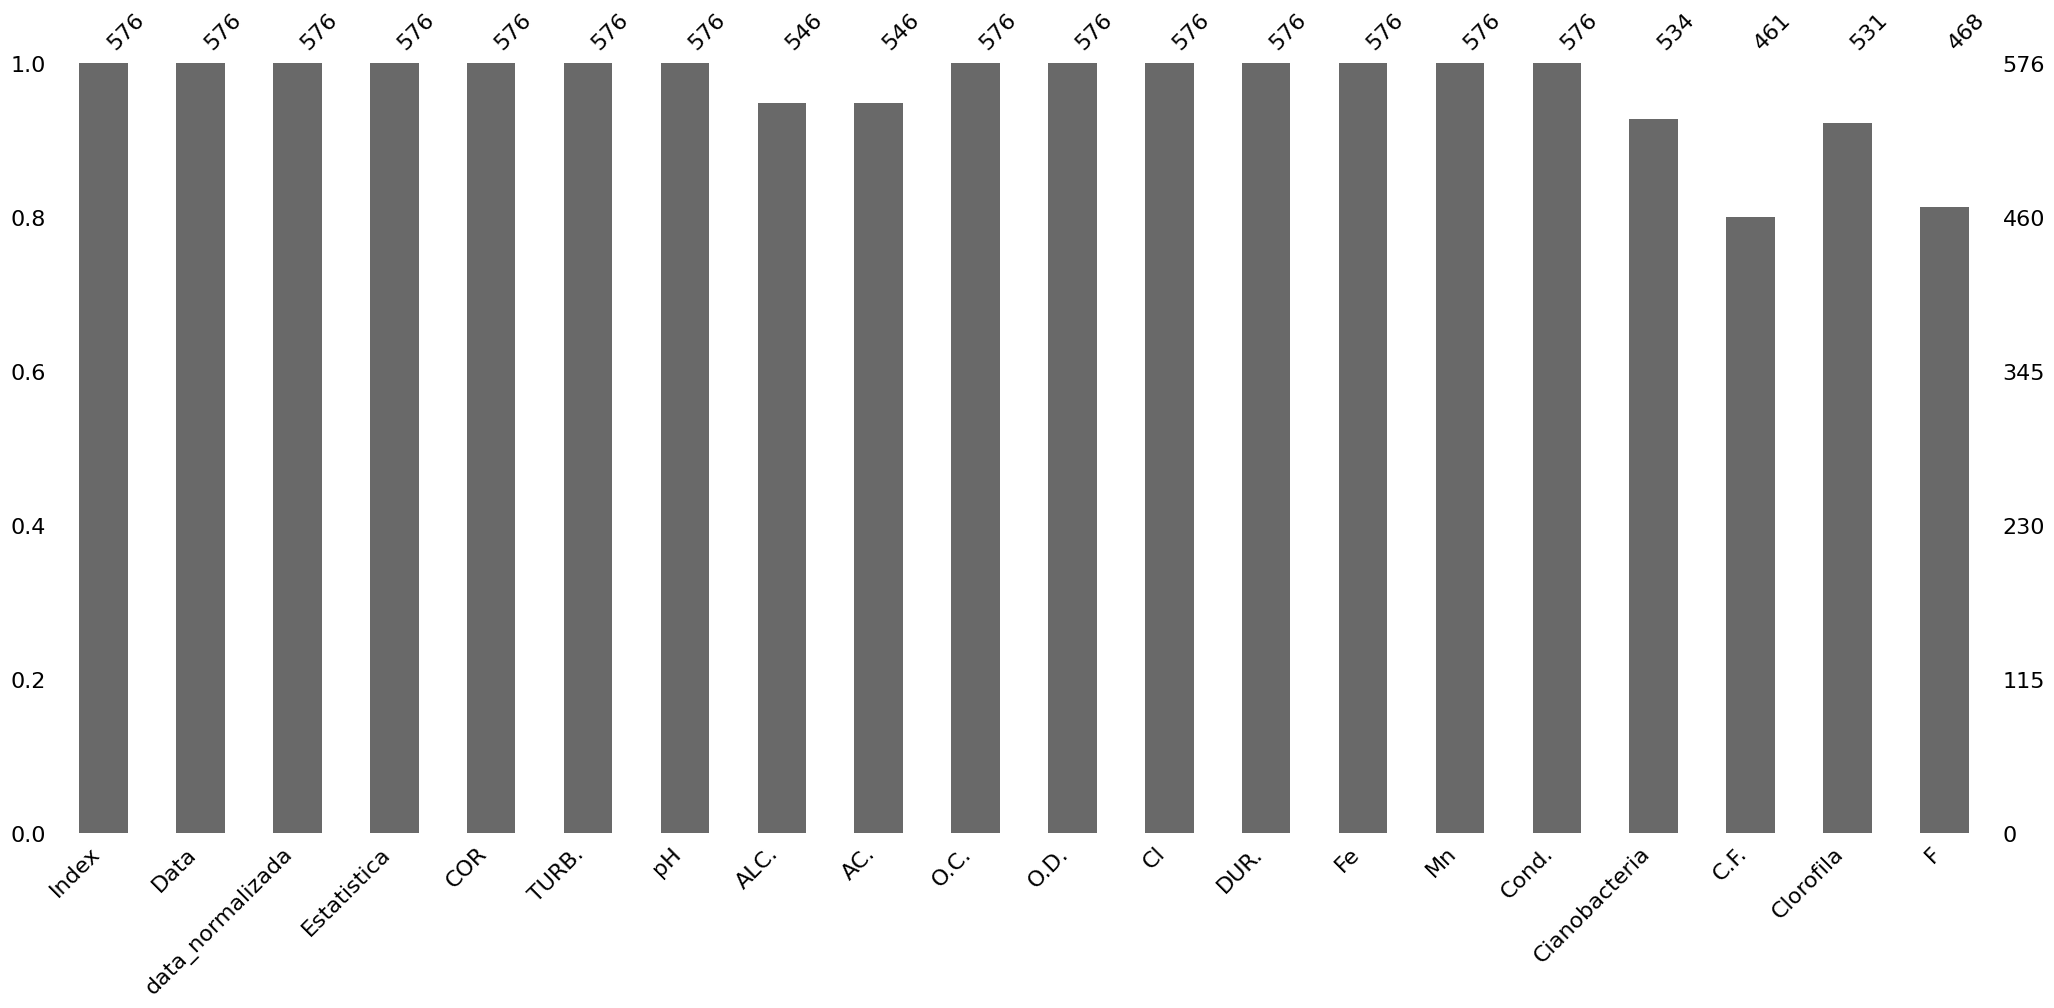

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\heatmap_msno_20260414_152043.png


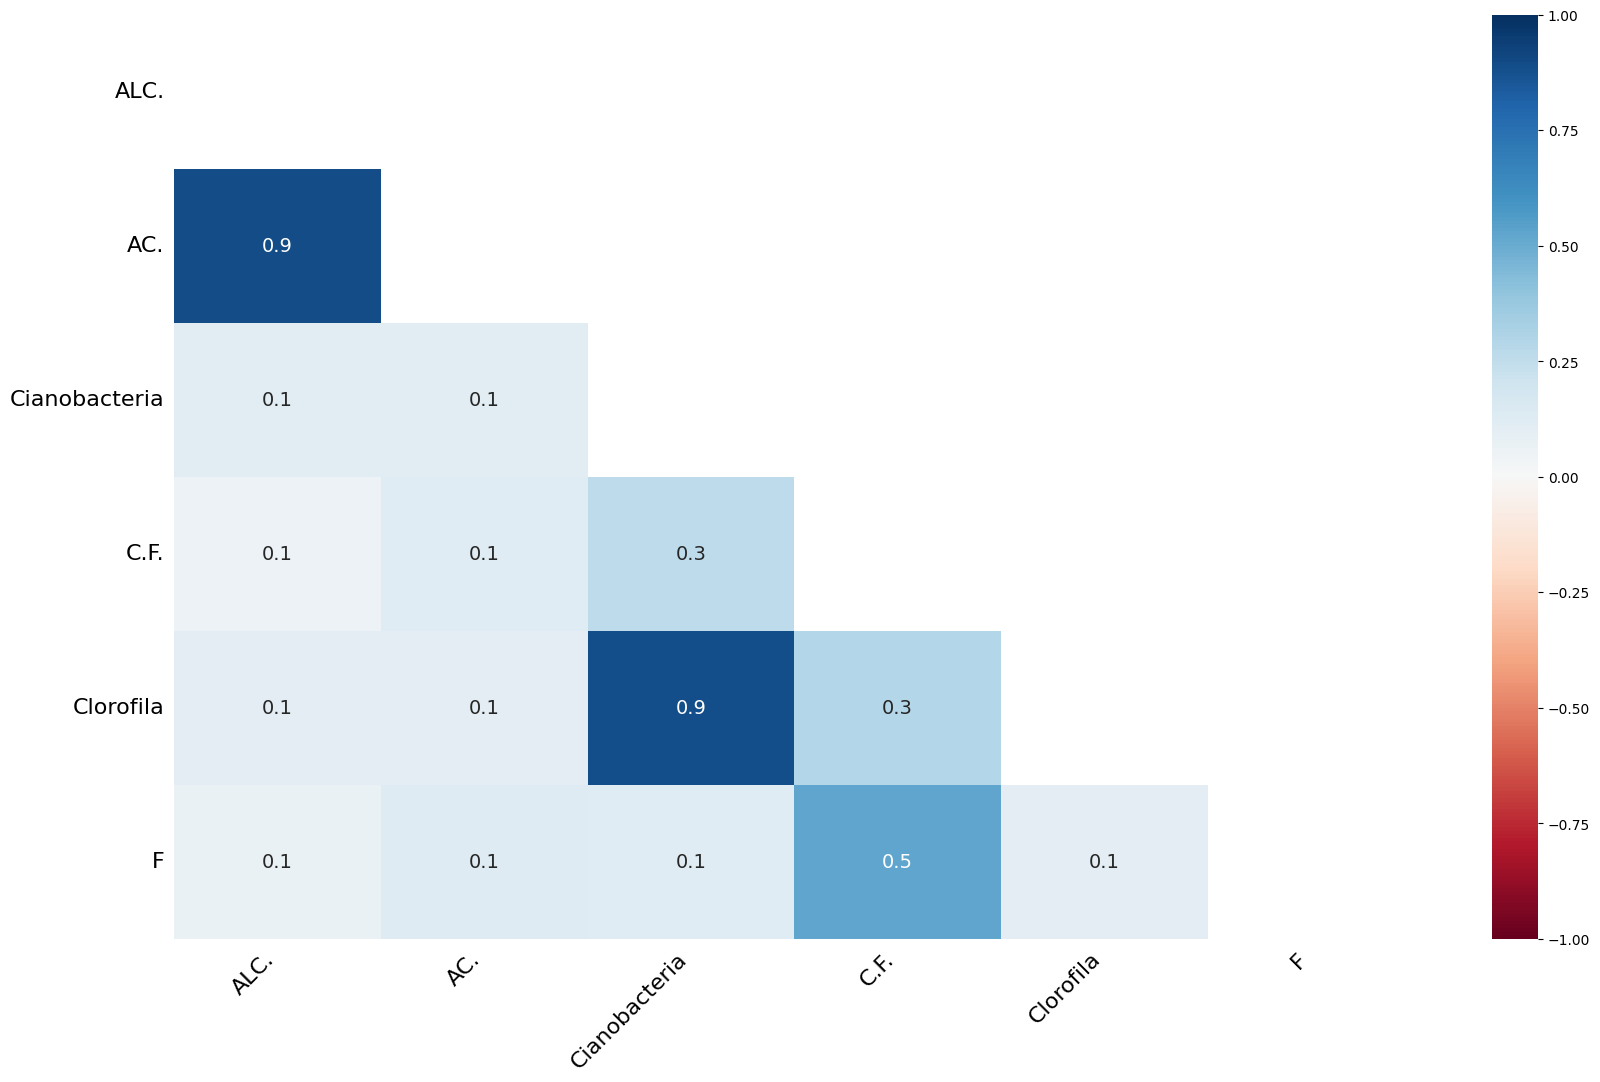

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\dendogram_msno_20260414_152043.png


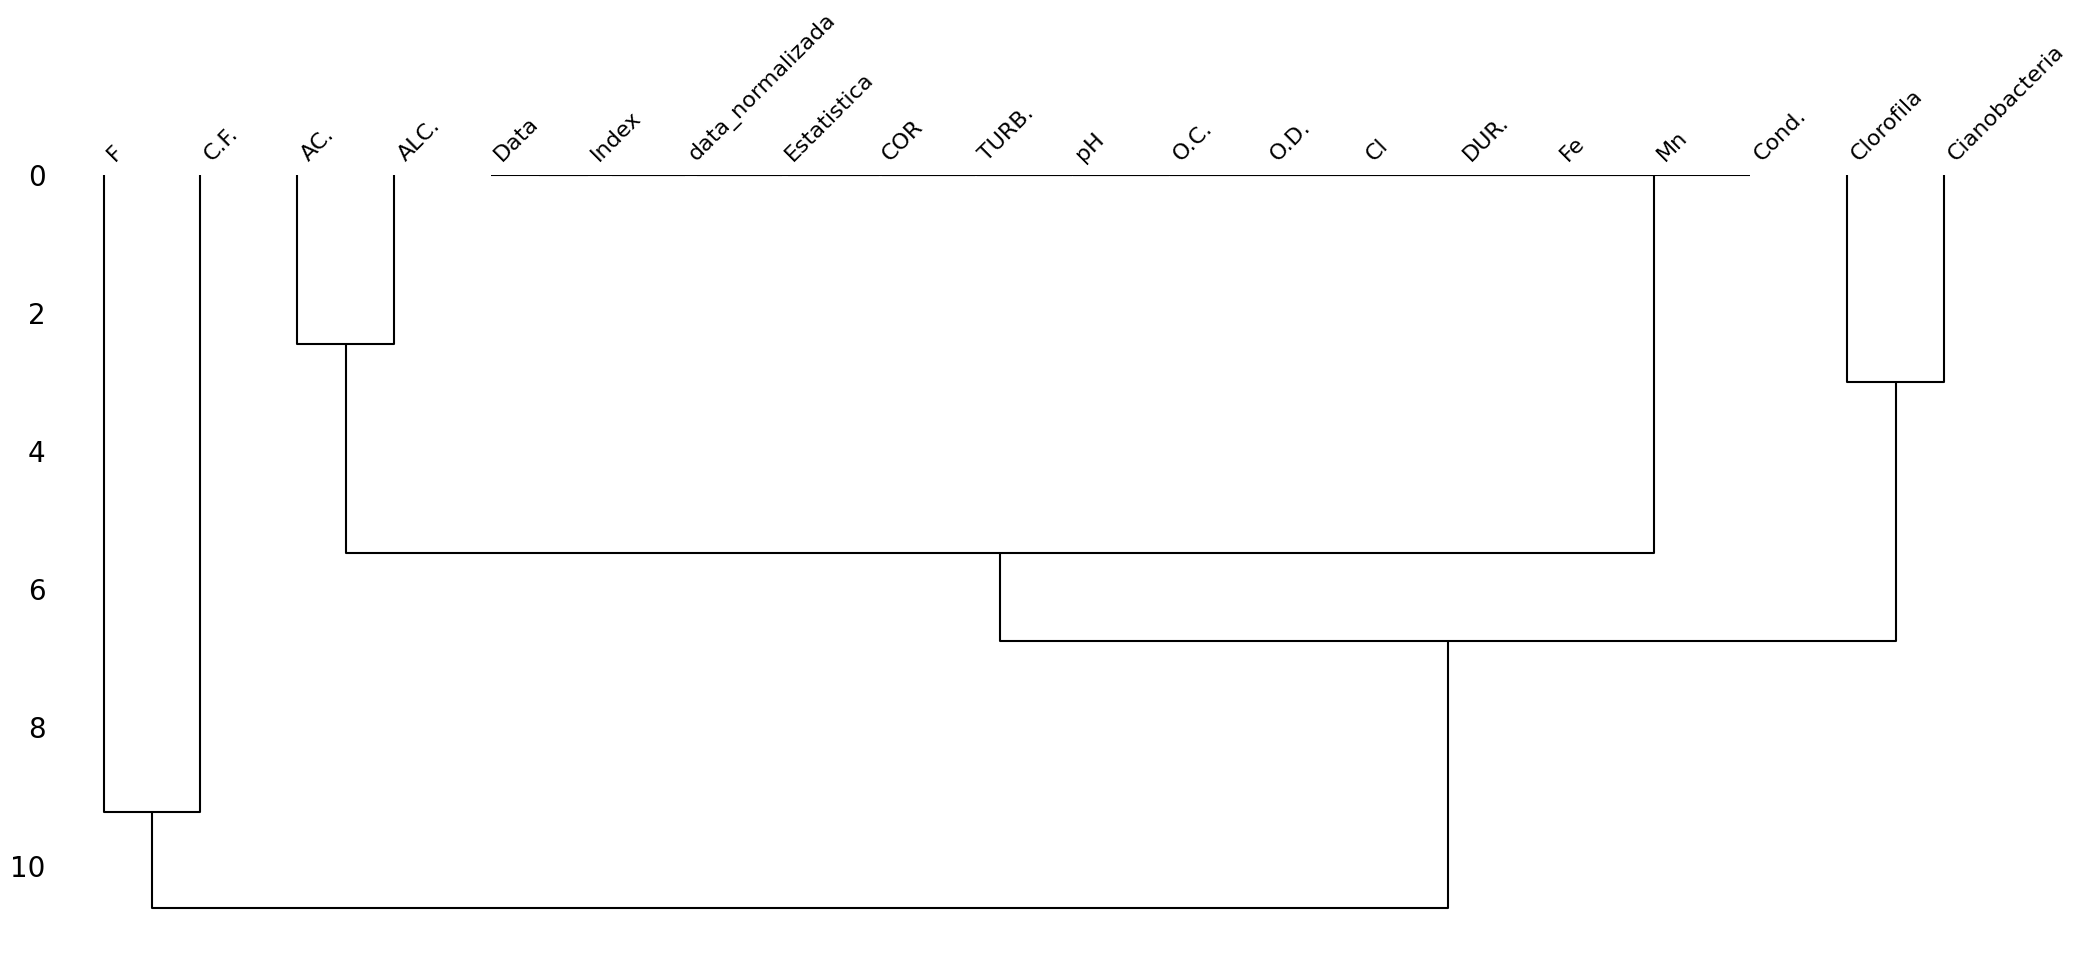

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_ano_20260414_152044.png


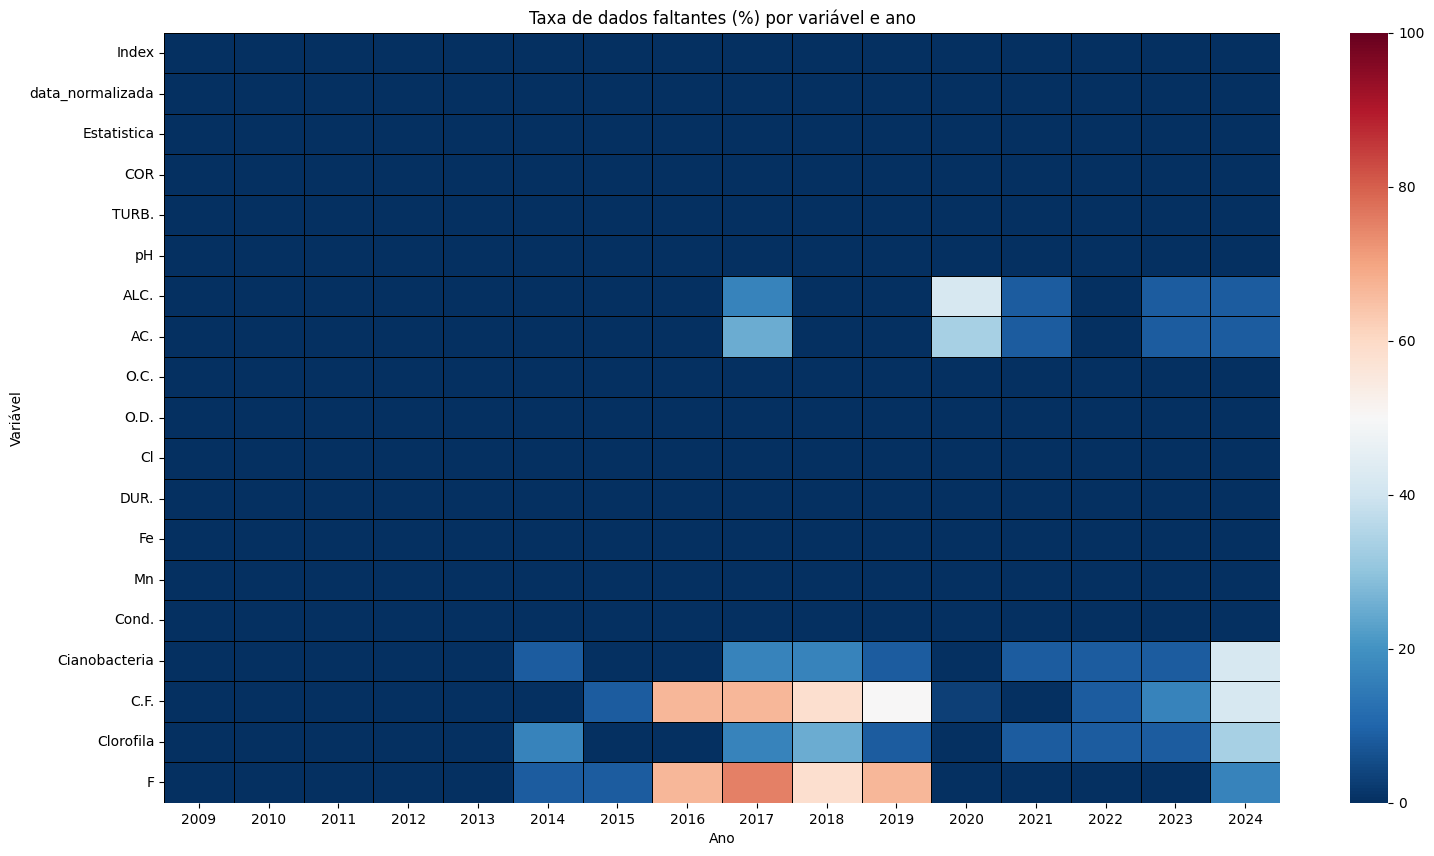

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_mes_20260414_152044.png


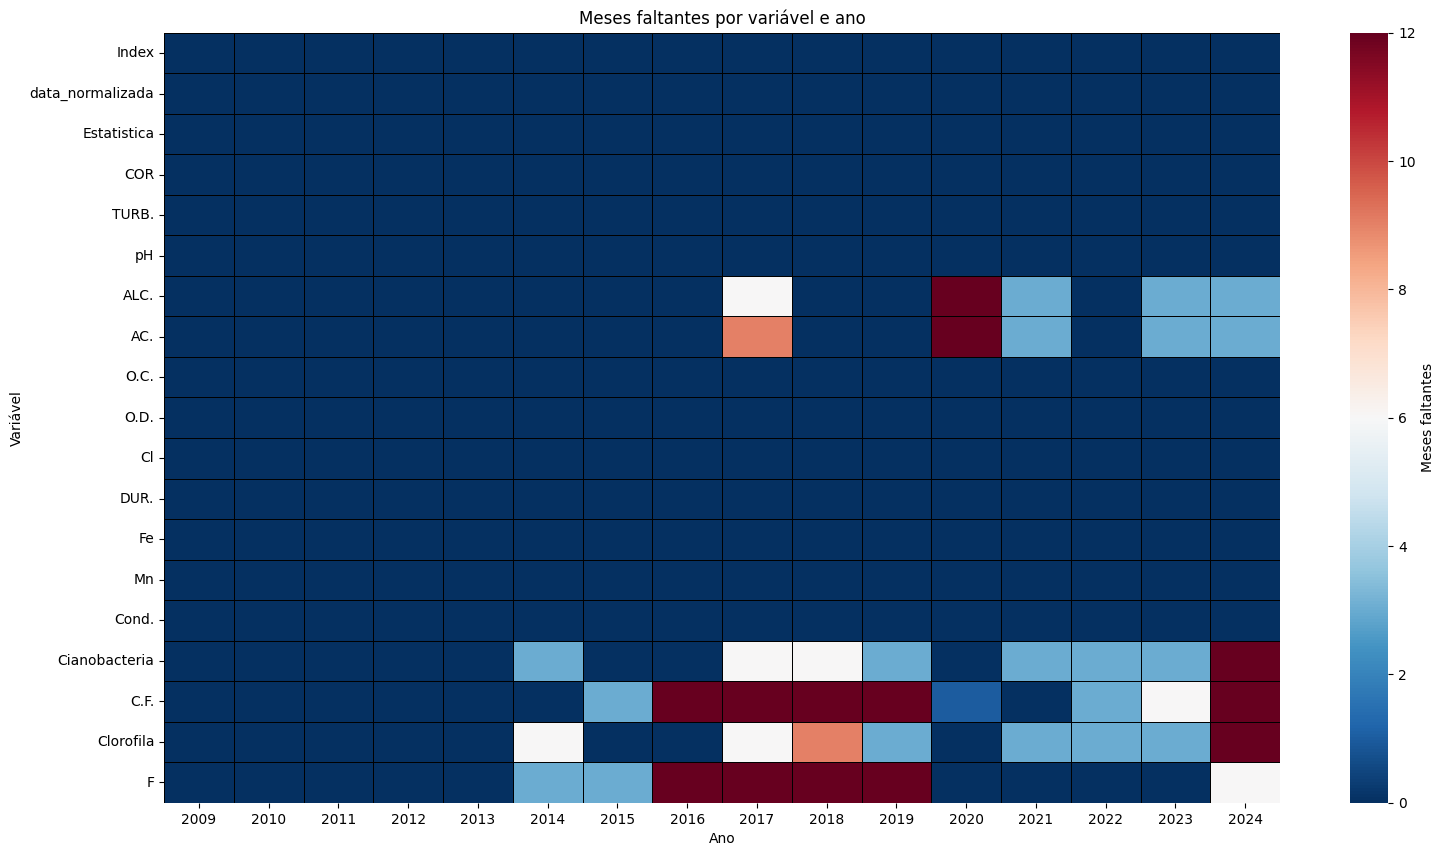

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\boxplot_tudo_20260414_152046.png


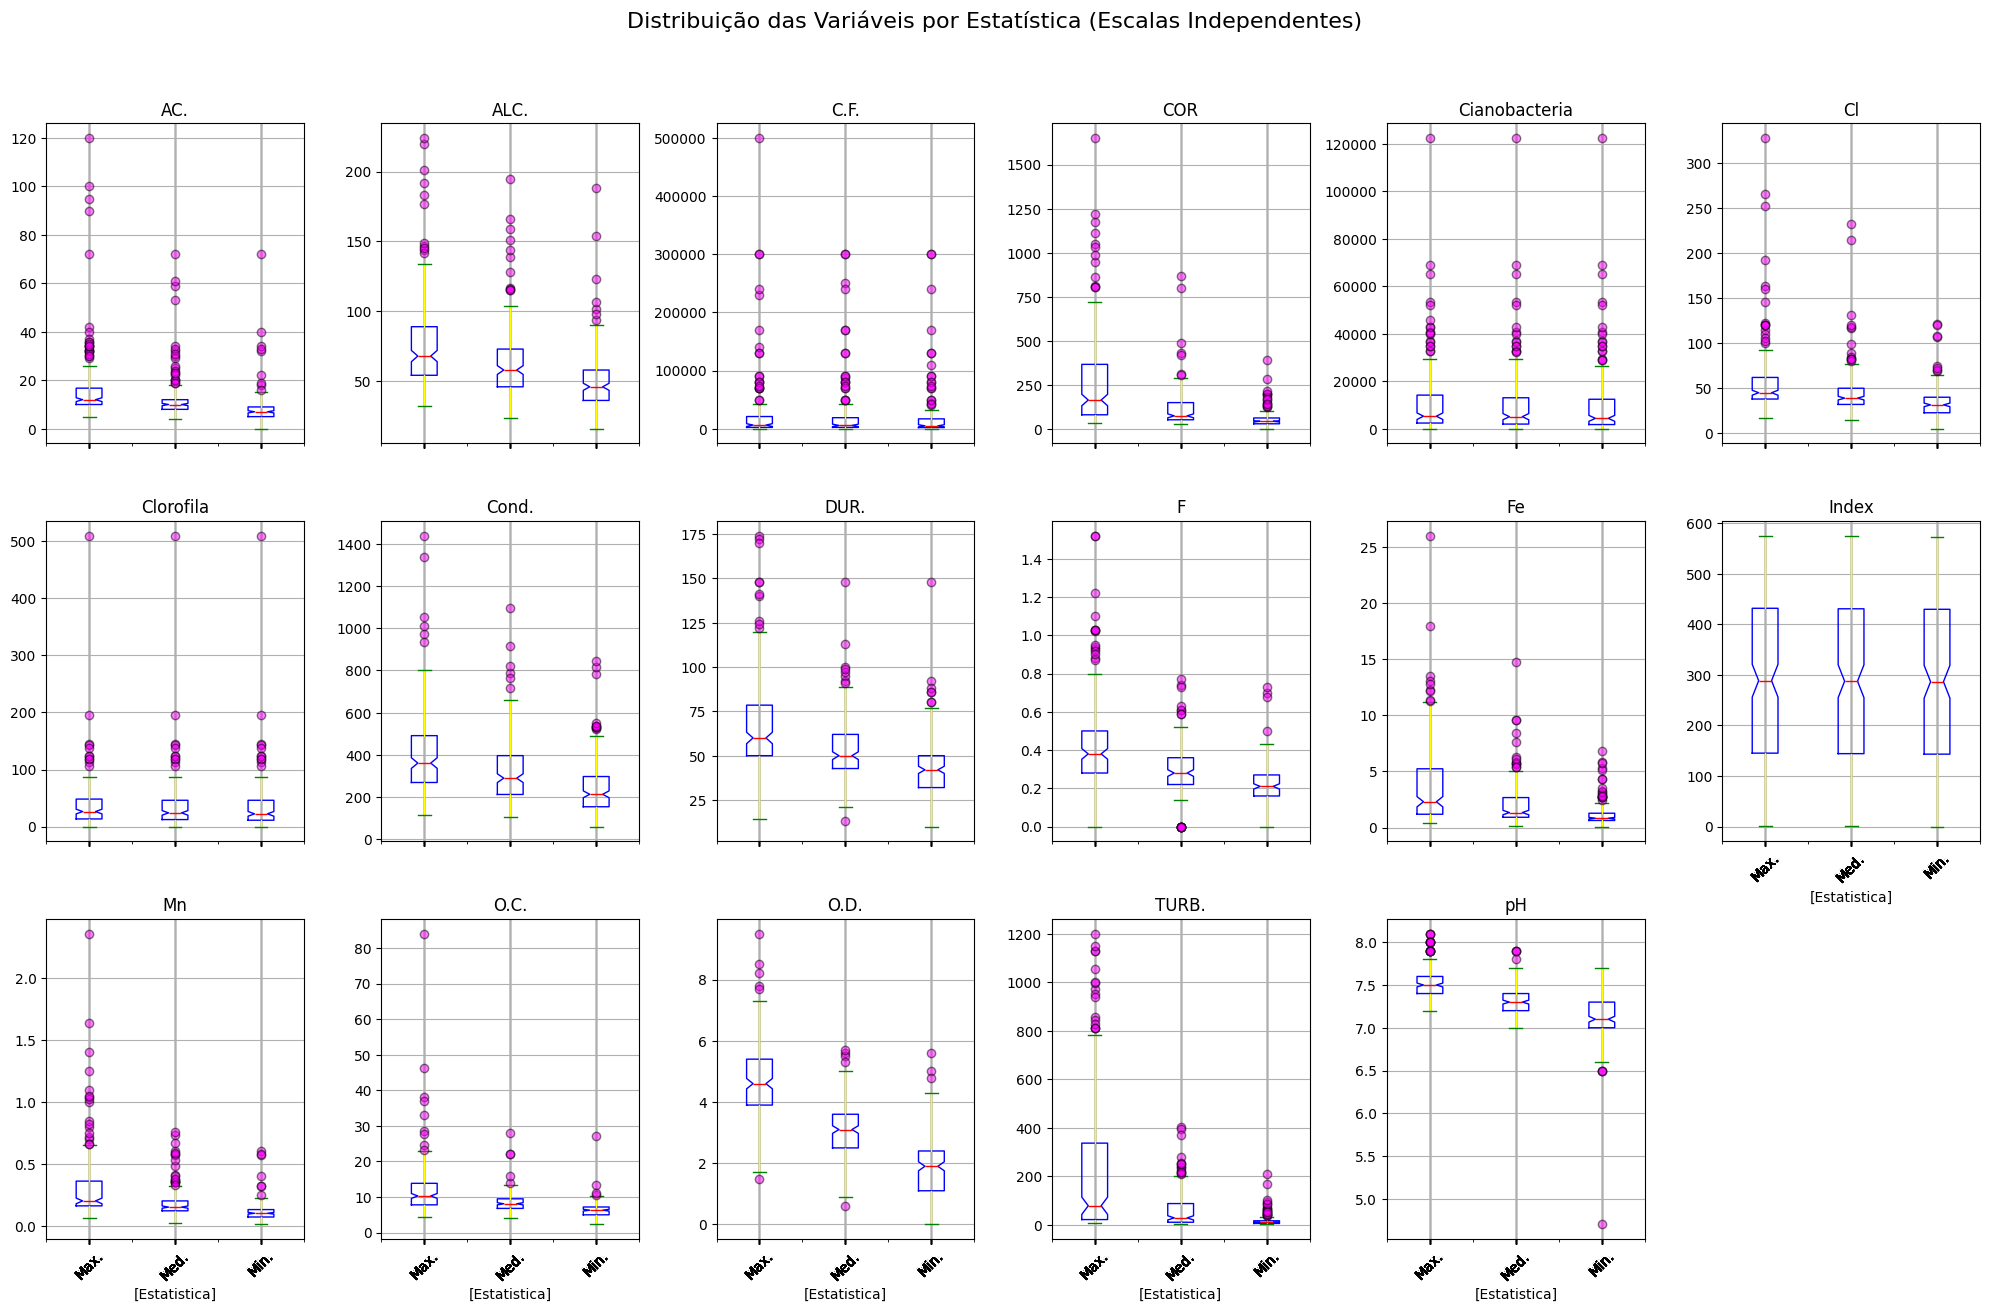

In [14]:
describe_imput_mediana = analise_descritiva(imput_mediana, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(imput_mediana)

In [15]:
## KNN
imput_KNN = knn_imput(dados_limpos, variaveis=variaveis)


Valores faltantes após imputação KNN:
COR              0
TURB.            0
pH               0
ALC.             0
AC.              0
O.C.             0
O.D.             0
Cl               0
DUR.             0
Fe               0
Mn               0
Cond.            0
Cianobacteria    0
C.F.             0
Clorofila        0
F                0
dtype: int64
Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\imput_knn20260414_152102.xlsx


c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['149.25305410122166' '191.74758909954386' '4.00000000000000'
 '46.00000000000000' '75.00000000000000' '171.00000000000000'
 '1650.00000000000000']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['102.21989528795811' '196.00702868139911' '1.00000000000000'
 '9.00000000000000' '21.50000000000000' '95.25000000000000'
 '1200.00000000000000']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dad

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\describe20260414_152106.xlsx
Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\matrix_msno_20260414_152107.png


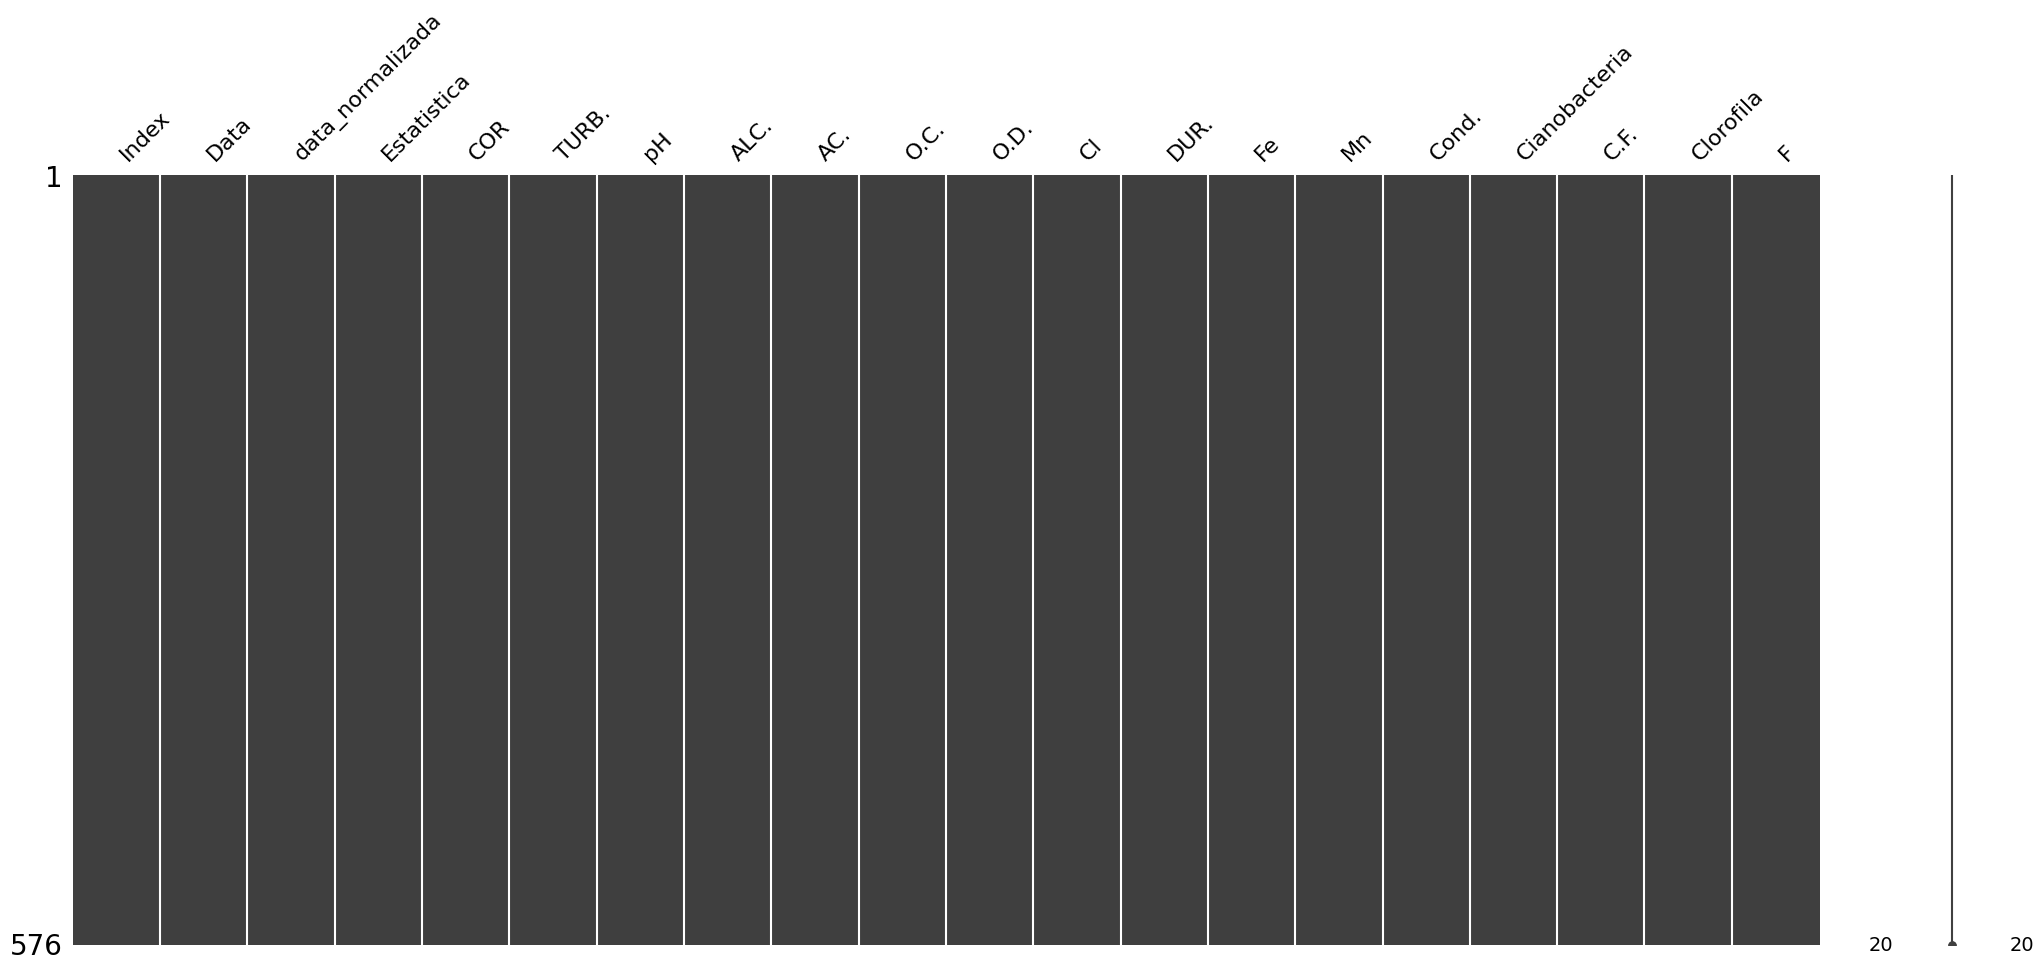

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\bar_msno_20260414_152107.png


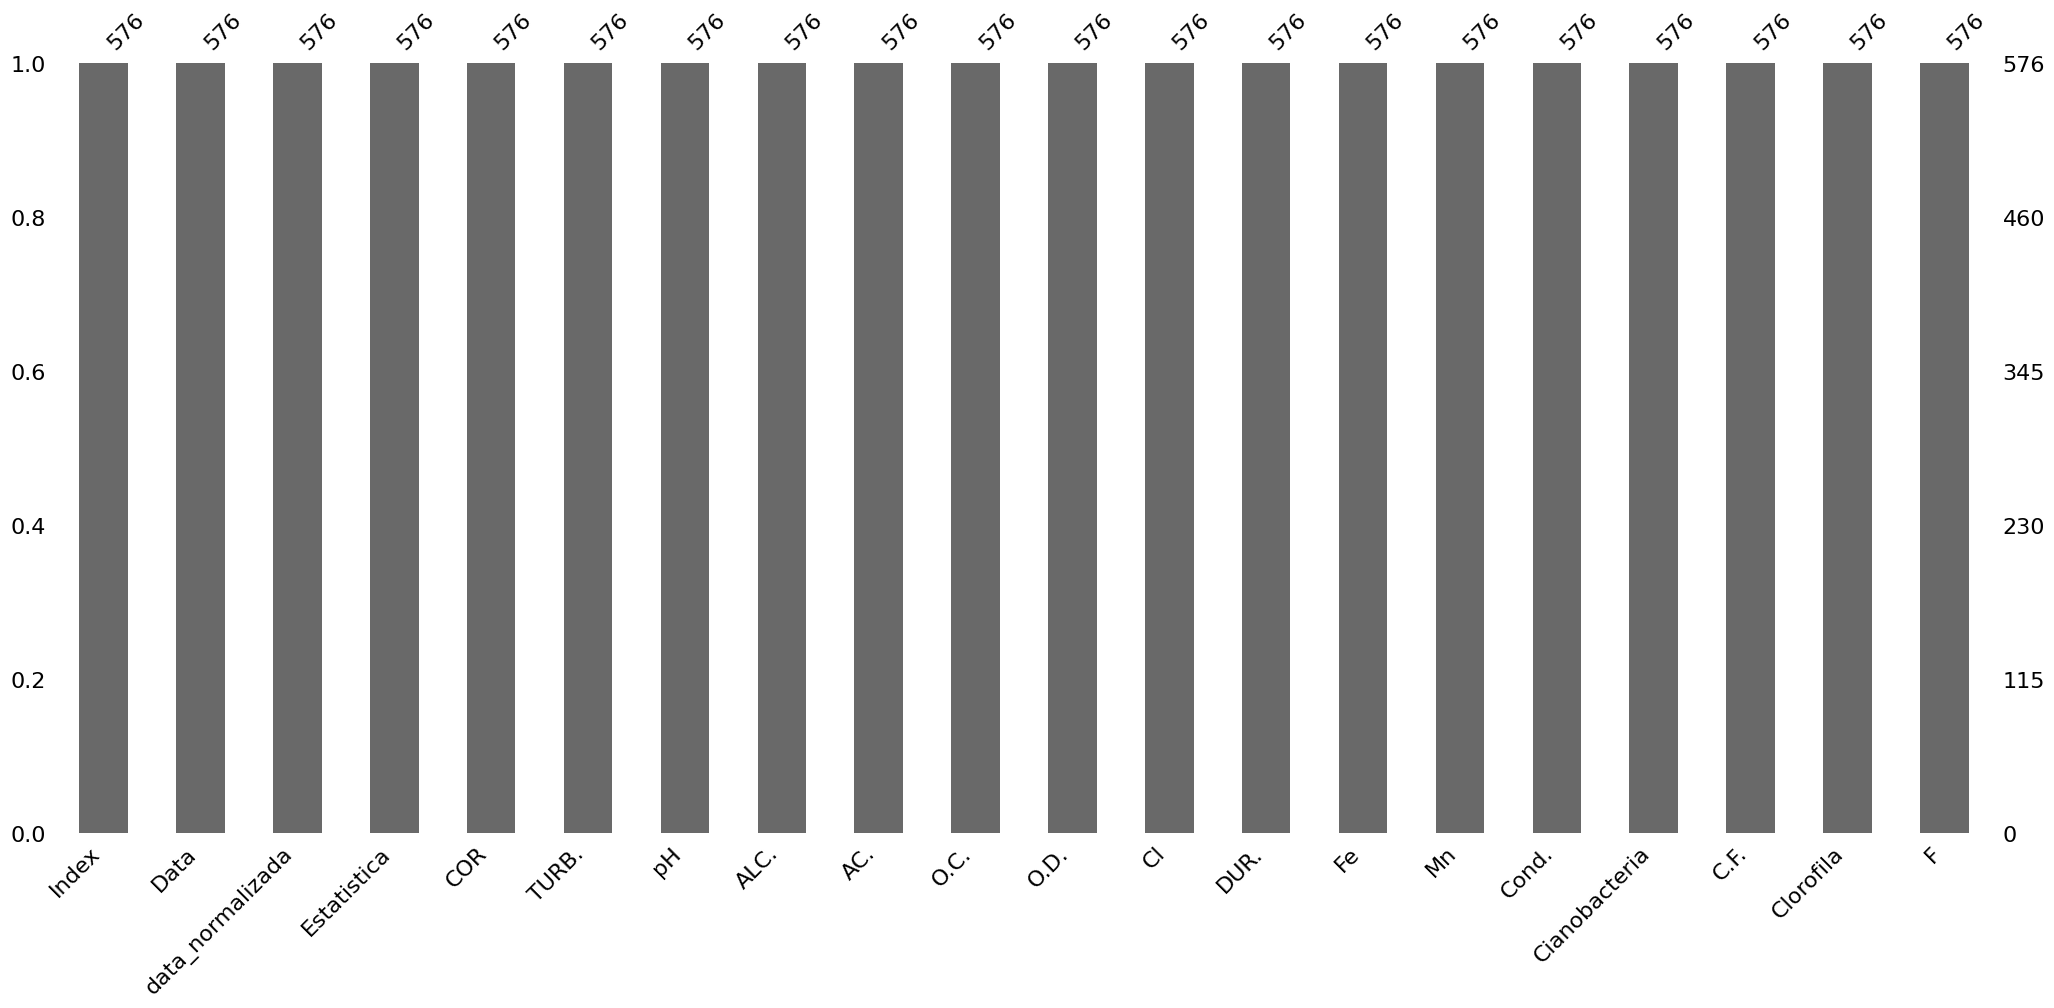

c:\_Master\programacao\Guilherme-Betta\IC2\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\_Master\programacao\Guilherme-Betta\IC2\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\heatmap_msno_20260414_152108.png


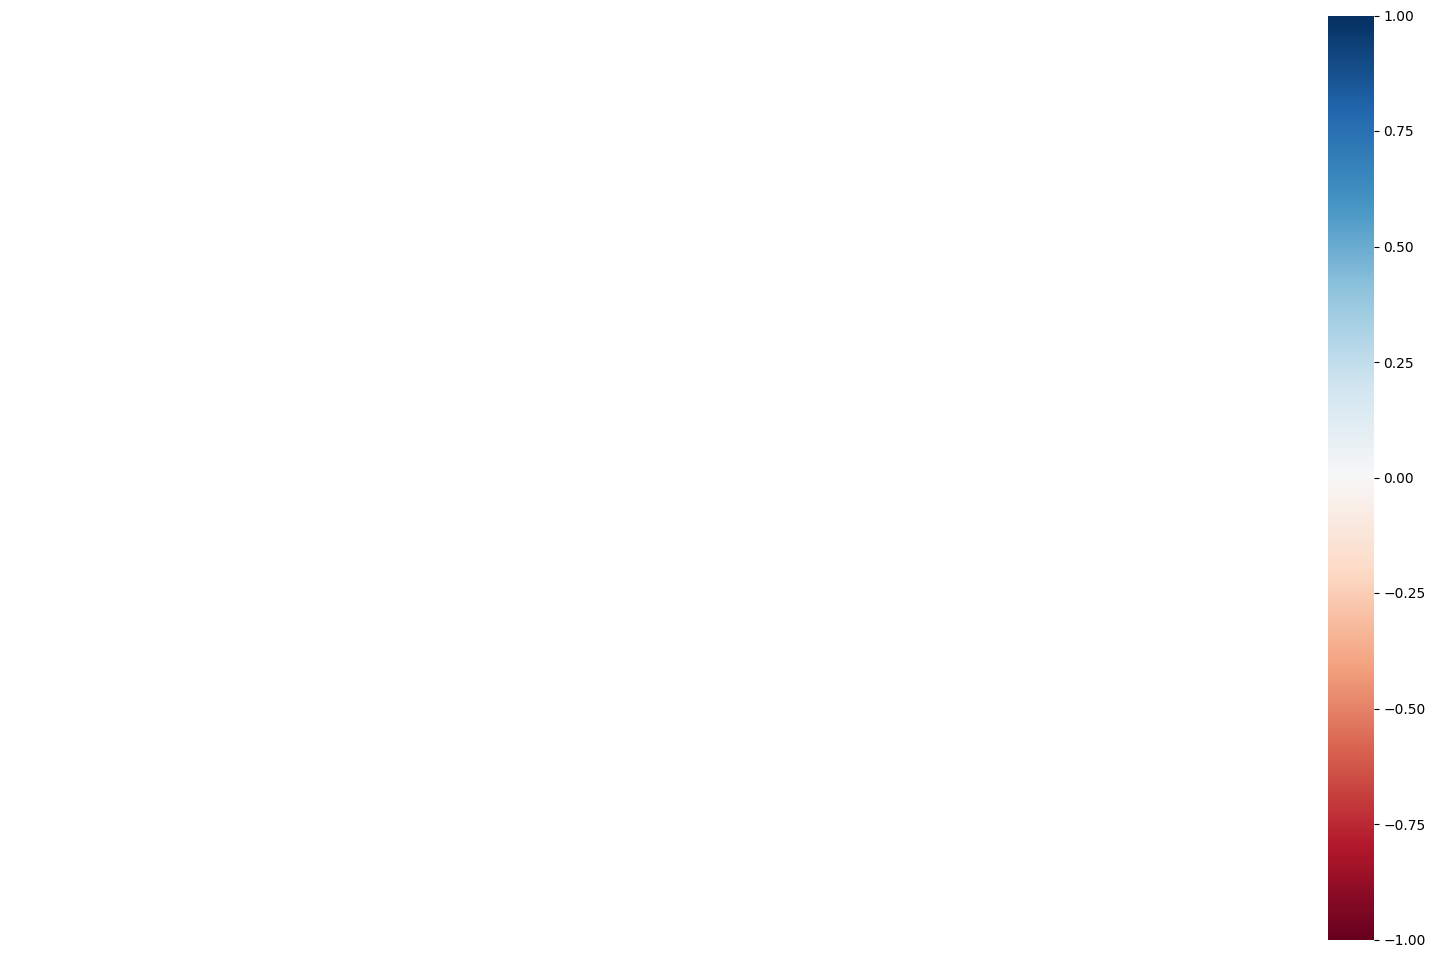

c:\_Master\programacao\Guilherme-Betta\IC2\.venv\Lib\site-packages\scipy\cluster\hierarchy.py:2950: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([dvw, 0])


Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\dendogram_msno_20260414_152108.png


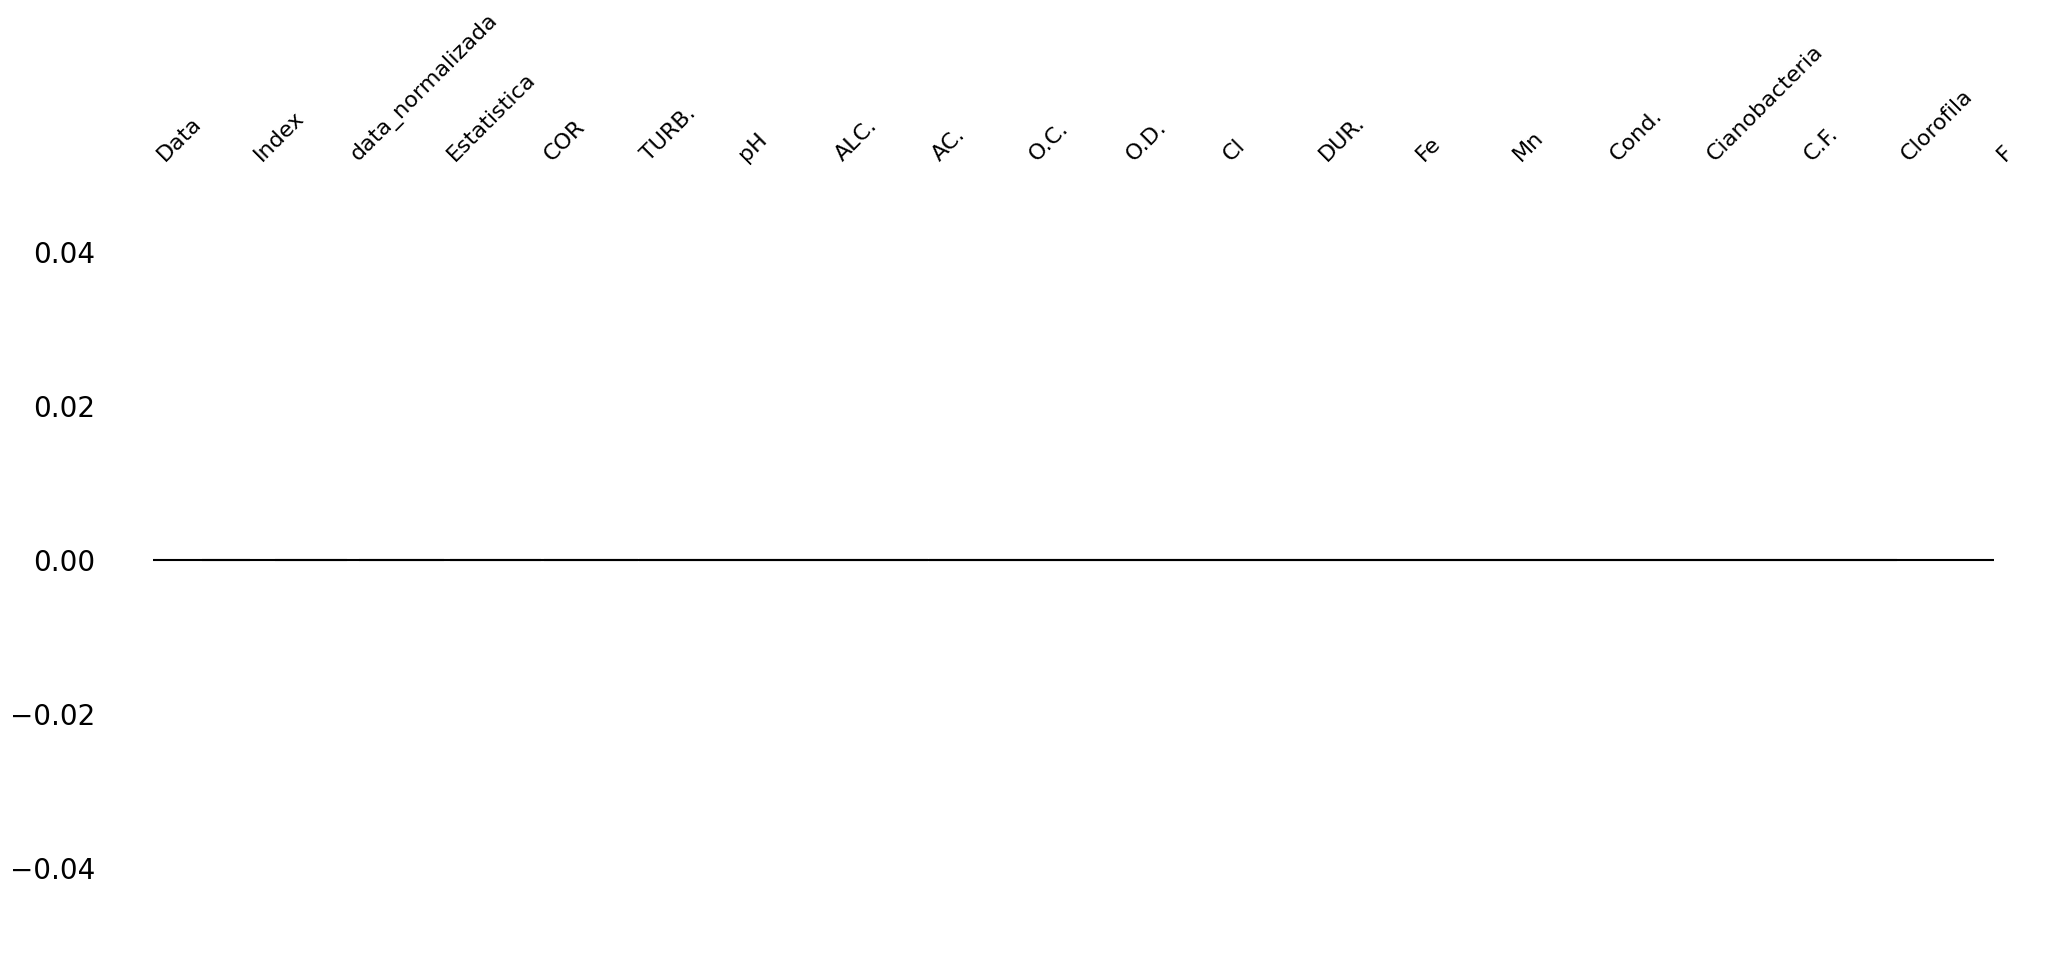

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_ano_20260414_152108.png


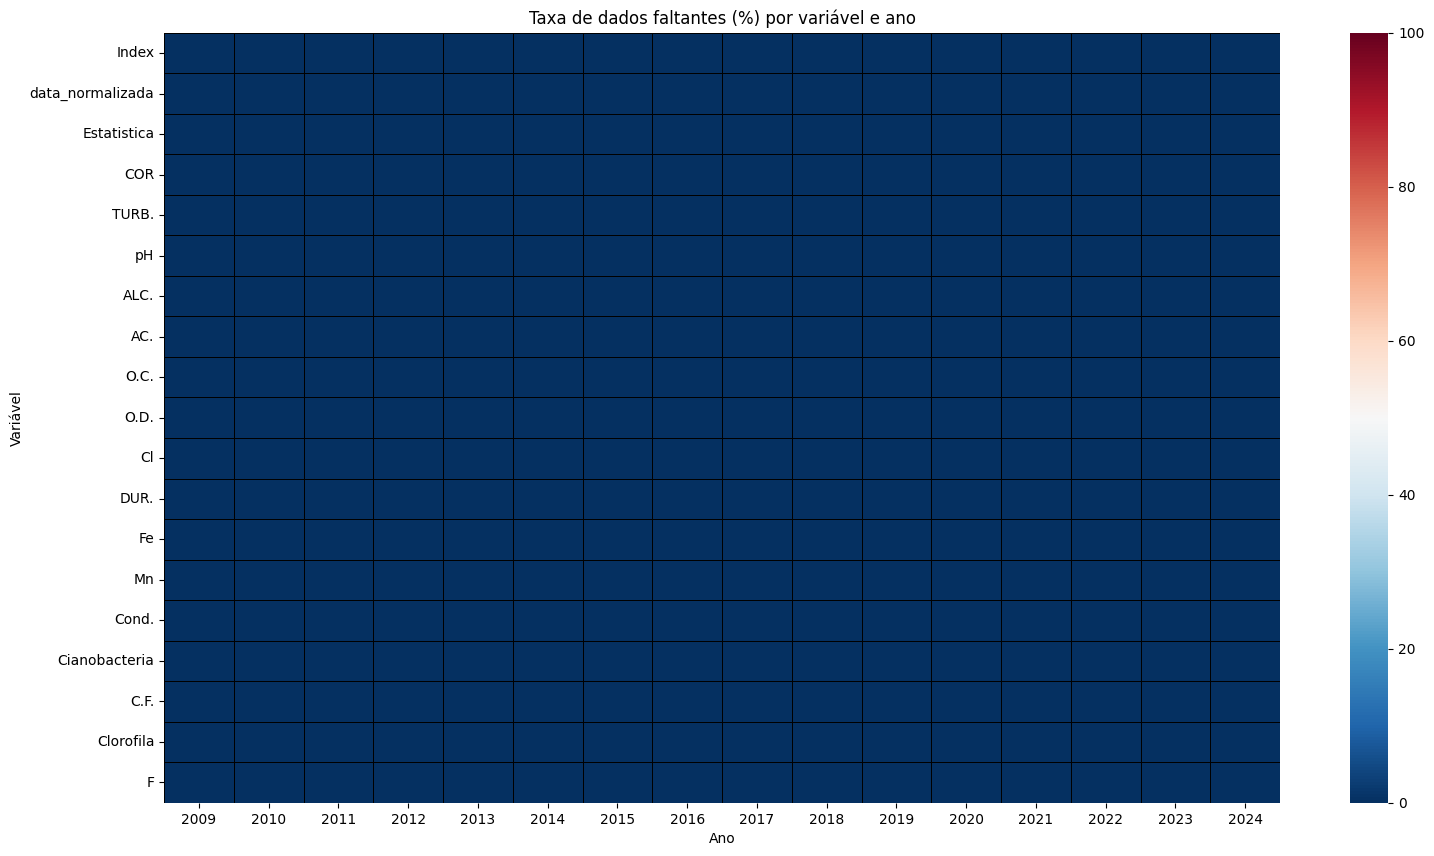

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_mes_20260414_152109.png


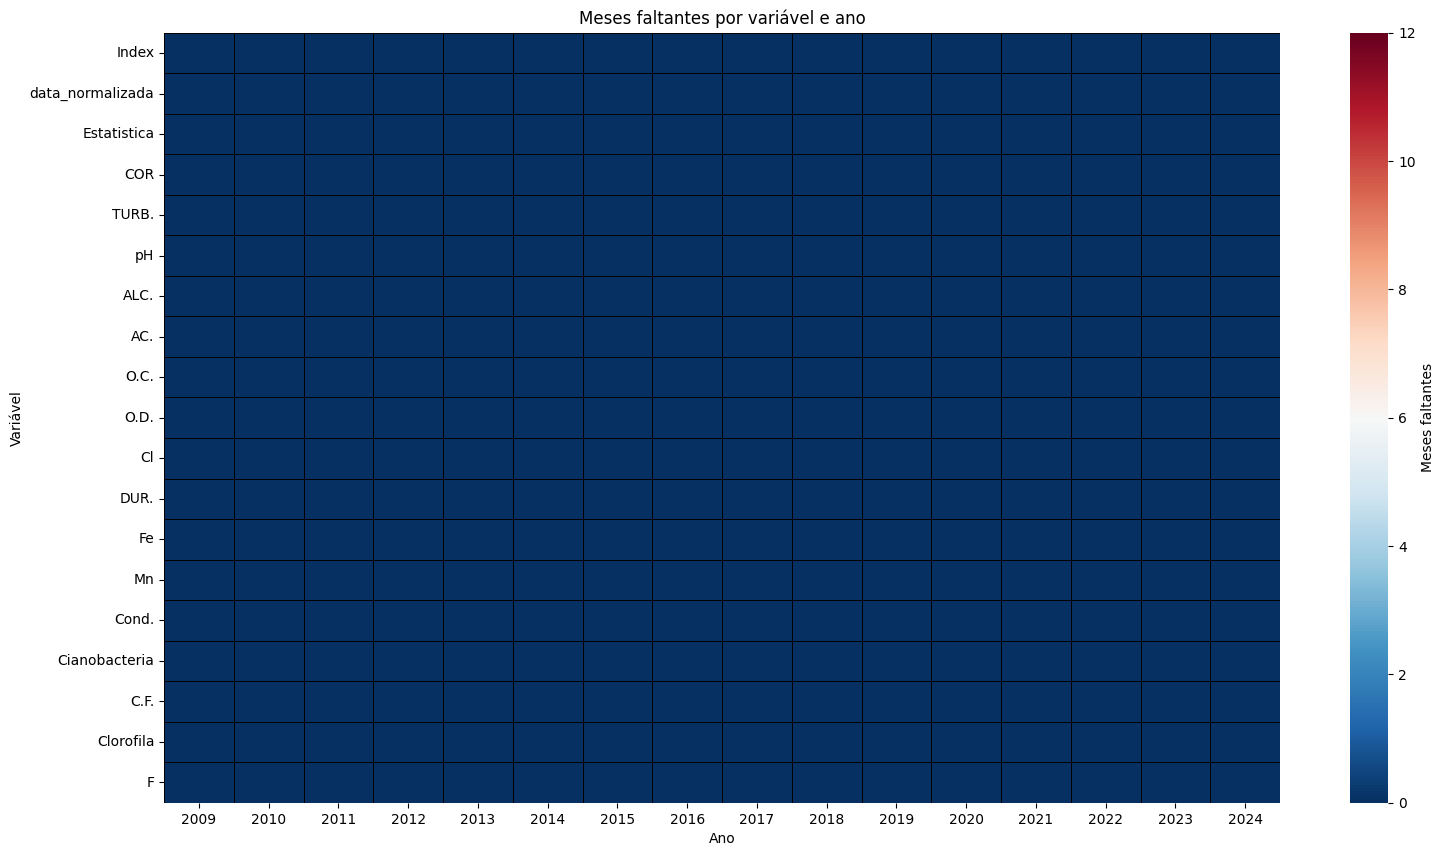

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\boxplot_tudo_20260414_152110.png


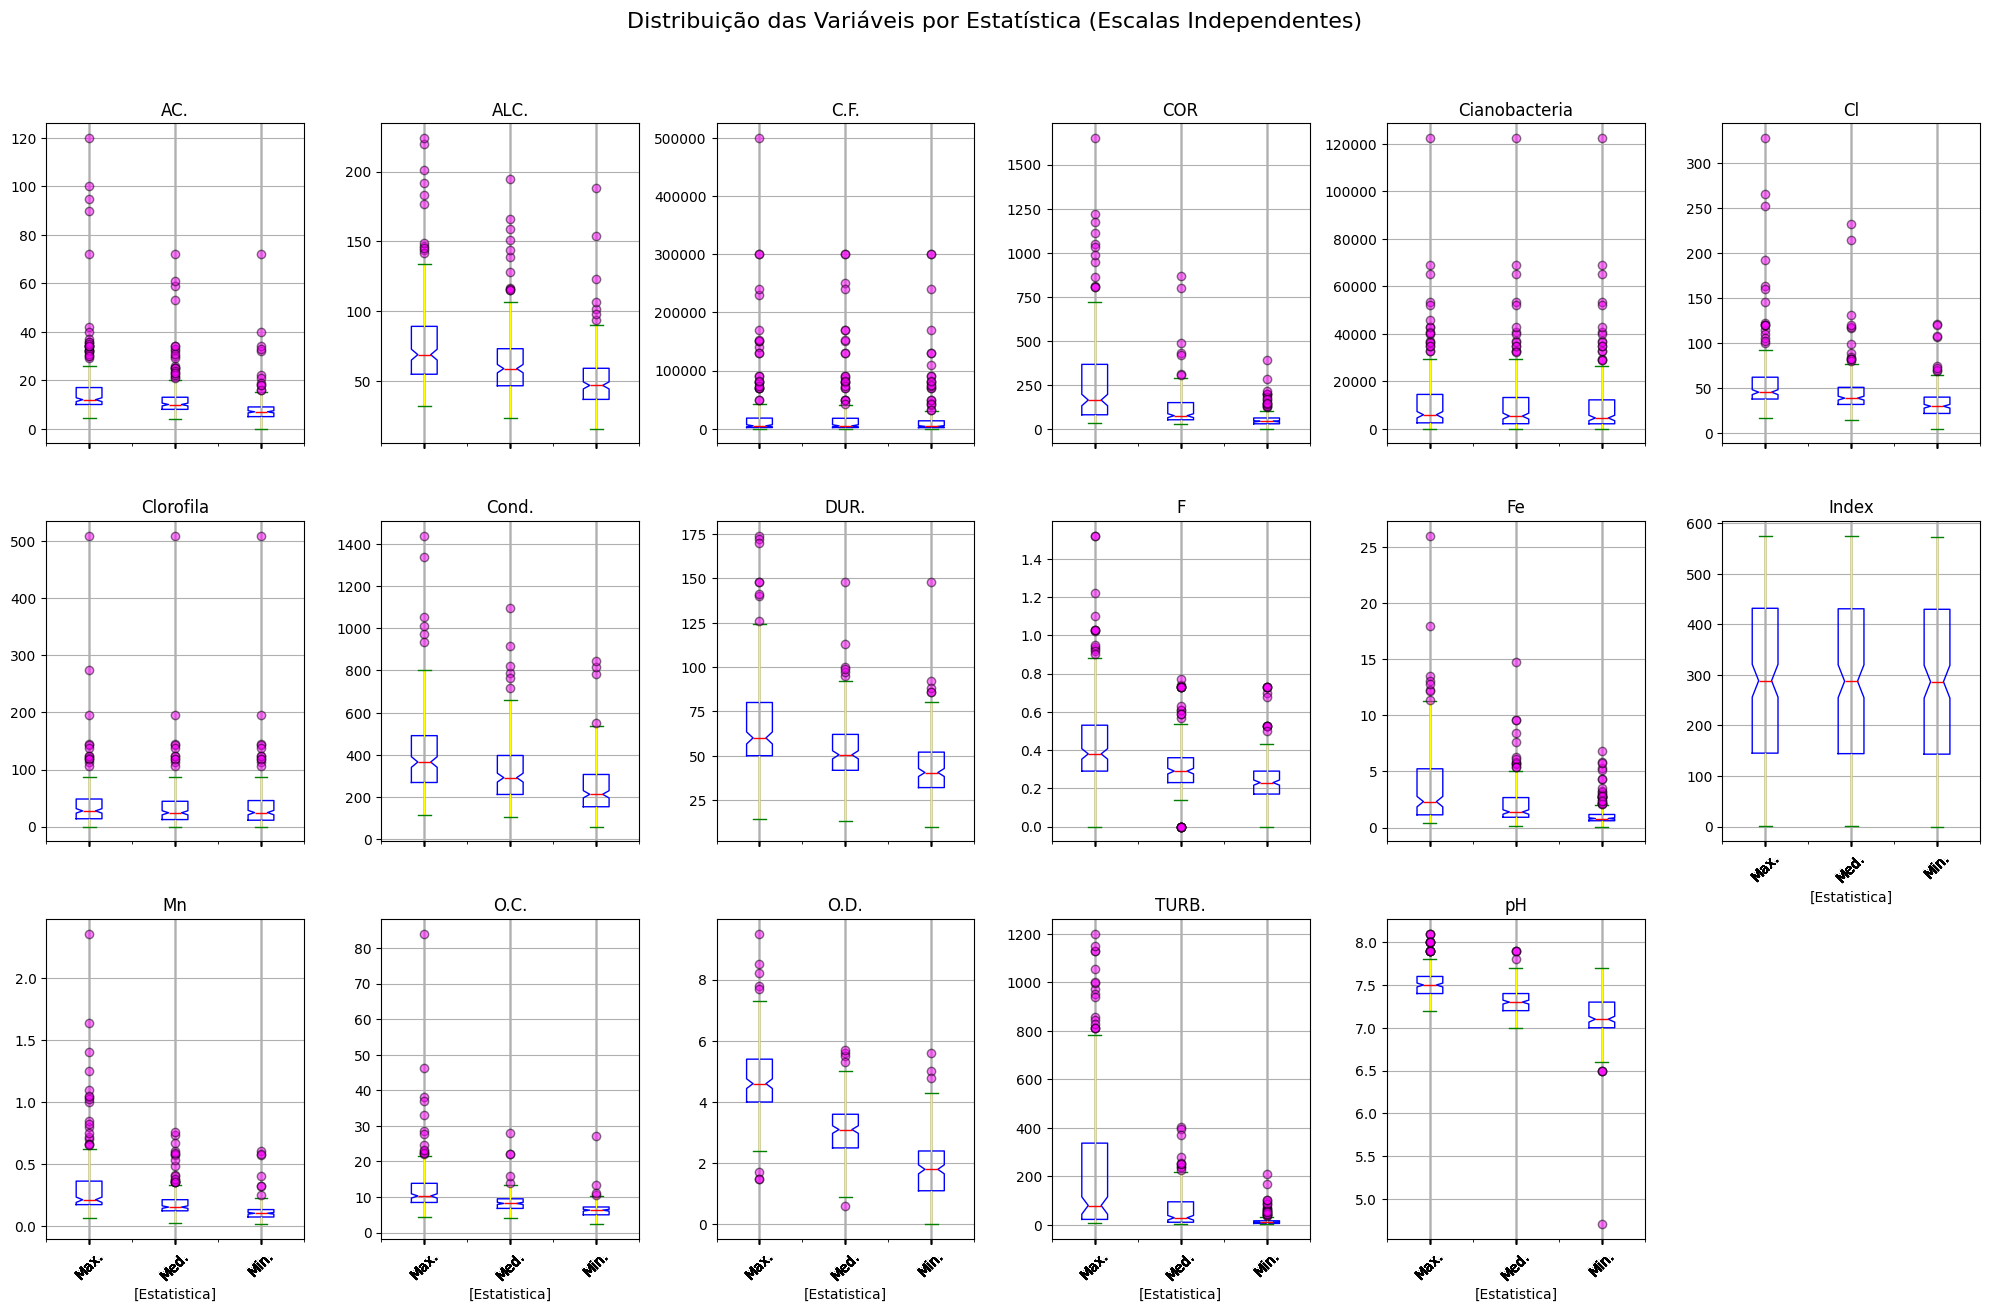

In [16]:
describe_imput_knn = analise_descritiva(imput_KNN, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(imput_KNN)

In [ ]:
## LOF
remocao_lof = remove_outliers(imput_KNN, variaveis=variaveis, method='lof') # Eu percebi que o único método que não deixou nenhum NaN foi o KNN
                                                                            # Talvez valha investigar o porquê disso, mas, por hora, vou usar como método
                                                                            # Para a remoção de outliers via LOF

Número de outliers detectados pelo LOF: 52
Score LOF mínimo: -5.063
Score LOF máximo: -0.939
Média dos scores LOF: -1.156
Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\outliers_removed_lof20260414_152444.xlsx


c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['148.03007473722076' '185.19631584986115' '4.00000000000000'
 '46.00000000000000' '74.50000000000000' '177.00000000000000'
 '1220.00000000000000']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dados_matematicos.apply(
c:\_Master\programacao\Guilherme-Betta\IC2\analise_descritiva.py:134: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '['102.61194596538908' '195.86760424154070' '1.00000000000000'
 '9.00000000000000' '21.00000000000000' '99.50000000000000'
 '1200.00000000000000']' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  describe.loc[estatisticas_para_formatar, col] = dad

Arquivo salvo em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\describe20260414_152436.xlsx
Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\matrix_msno_20260414_152436.png


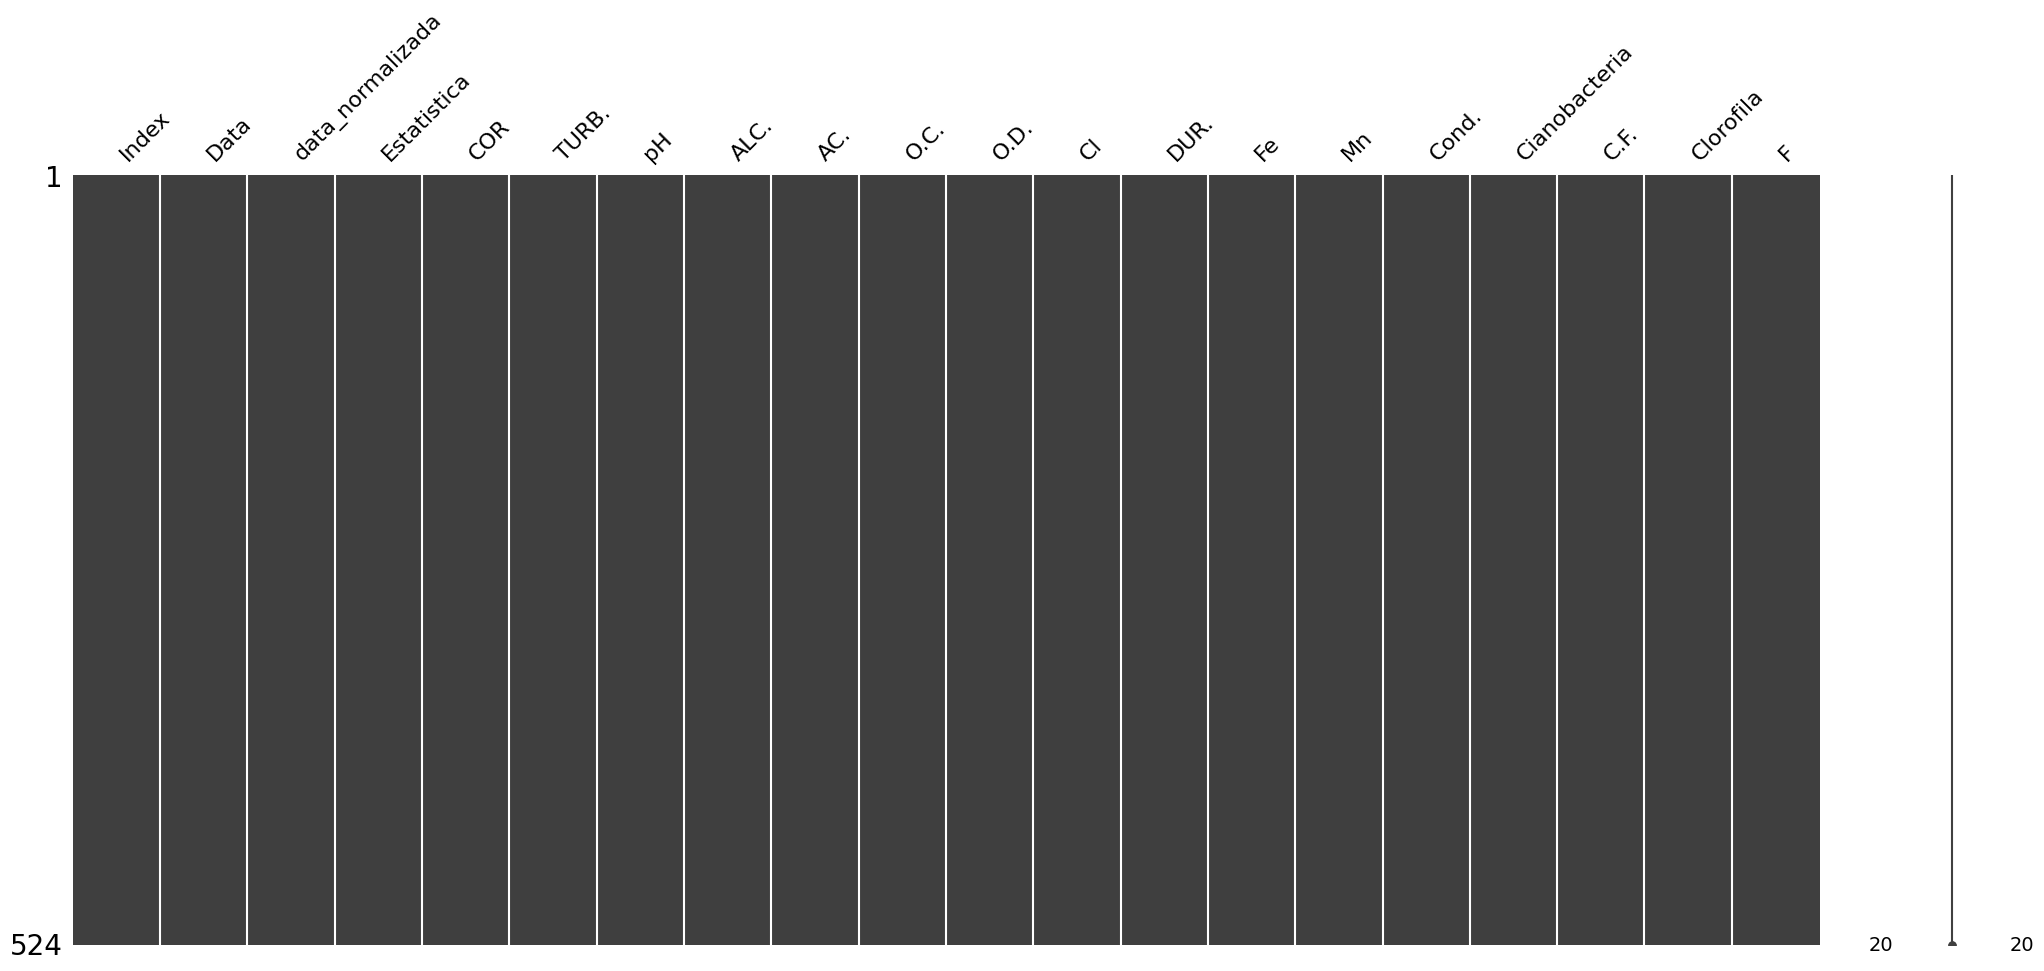

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\bar_msno_20260414_152437.png


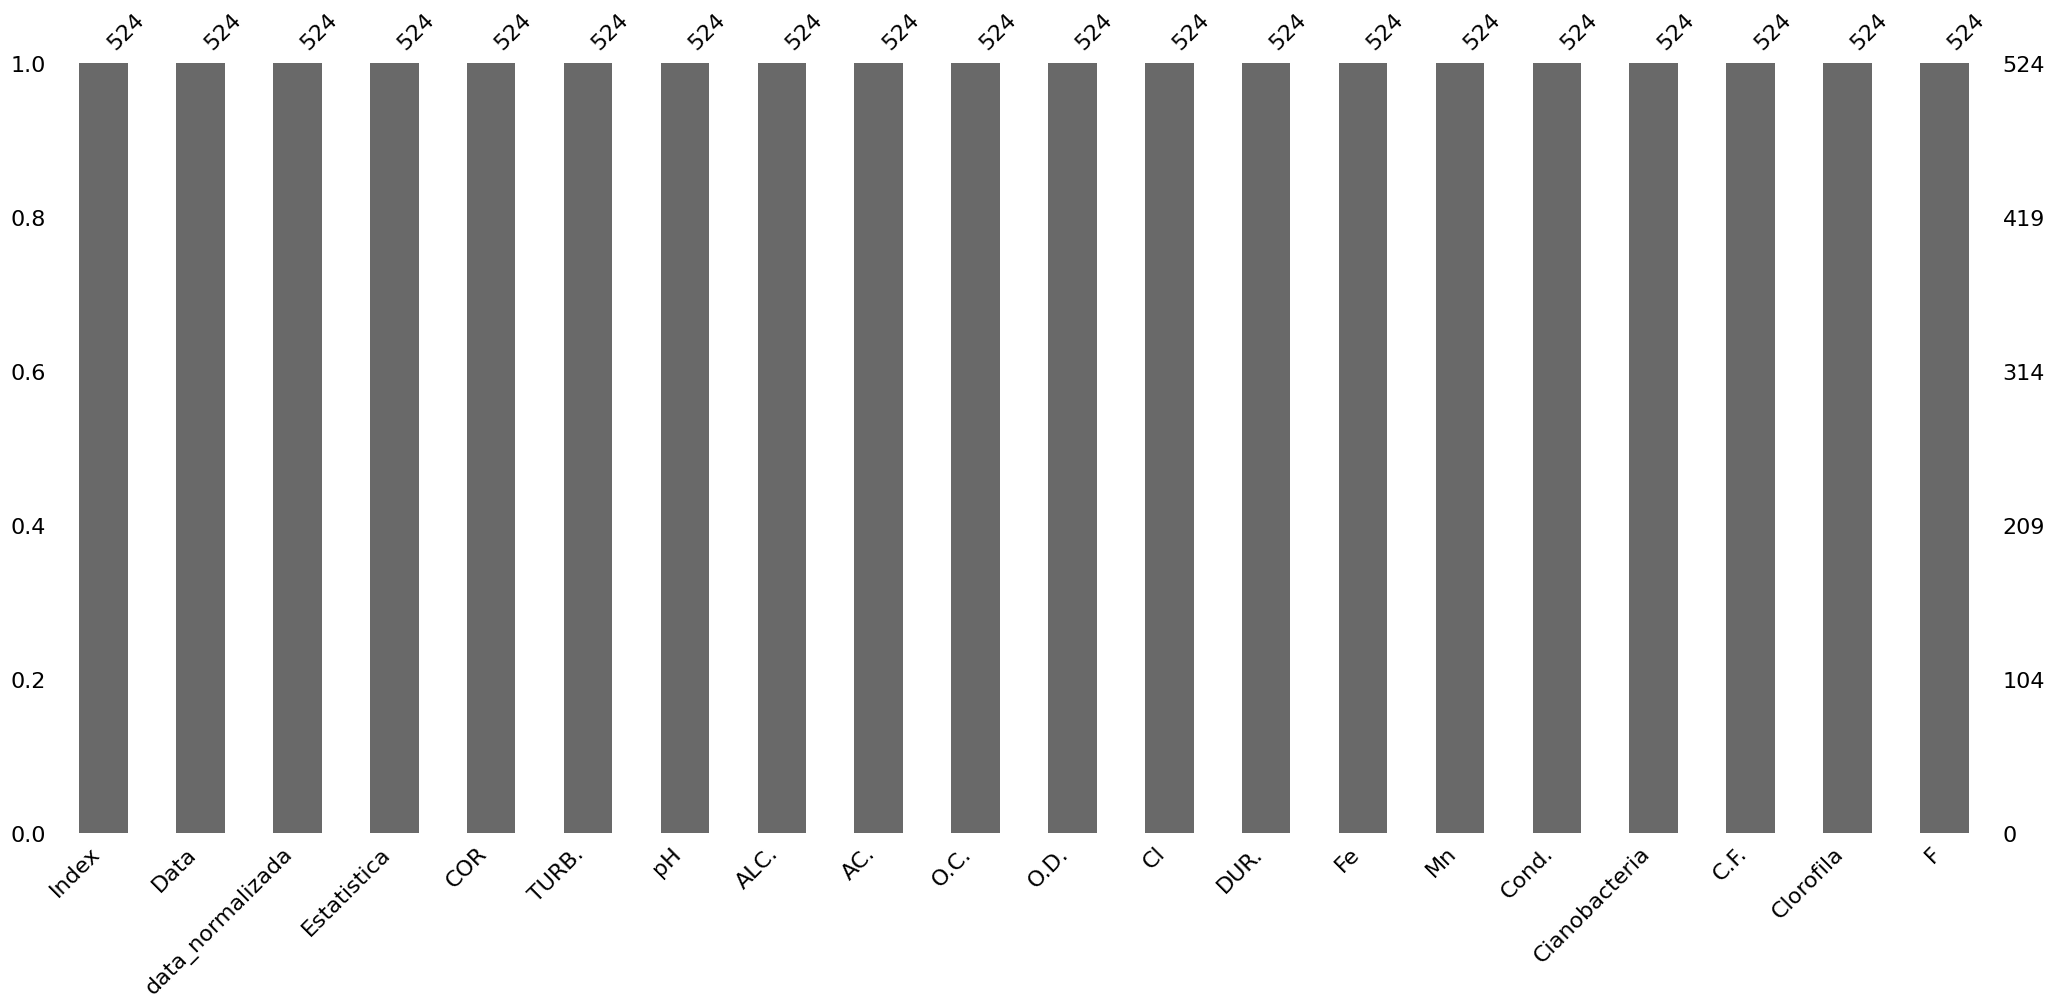

c:\_Master\programacao\Guilherme-Betta\IC2\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
c:\_Master\programacao\Guilherme-Betta\IC2\.venv\Lib\site-packages\seaborn\matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\heatmap_msno_20260414_152437.png


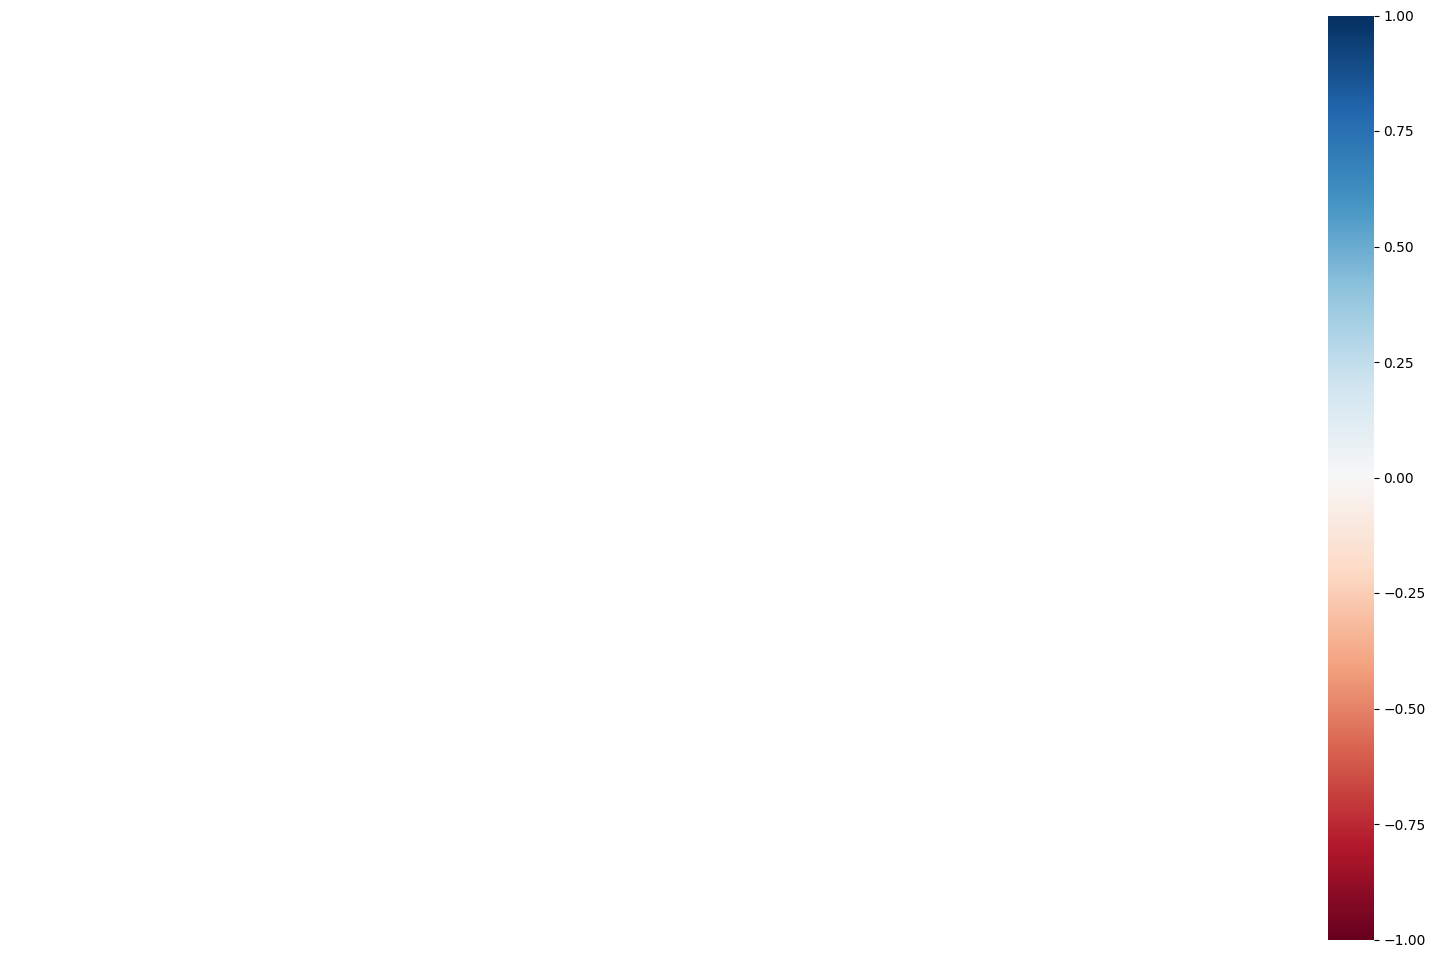

c:\_Master\programacao\Guilherme-Betta\IC2\.venv\Lib\site-packages\scipy\cluster\hierarchy.py:2950: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([dvw, 0])


Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\dendogram_msno_20260414_152438.png


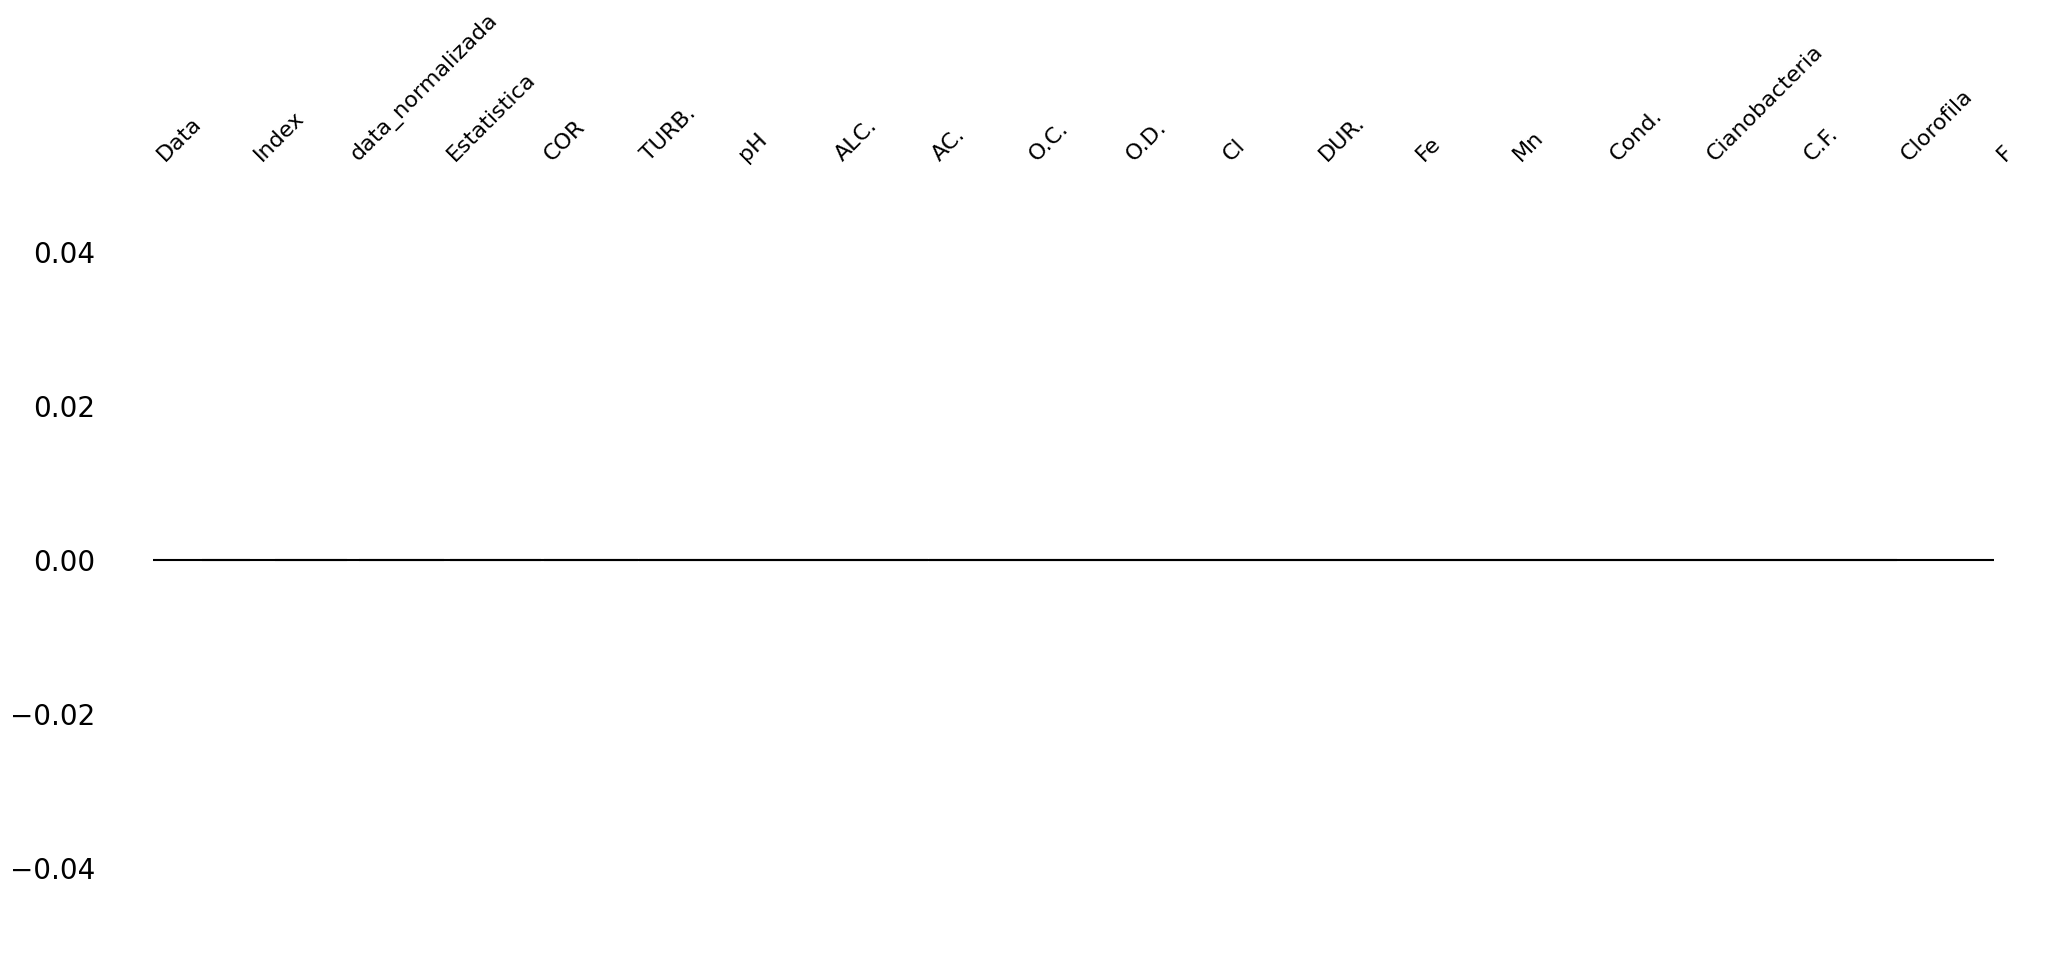

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_ano_20260414_152438.png


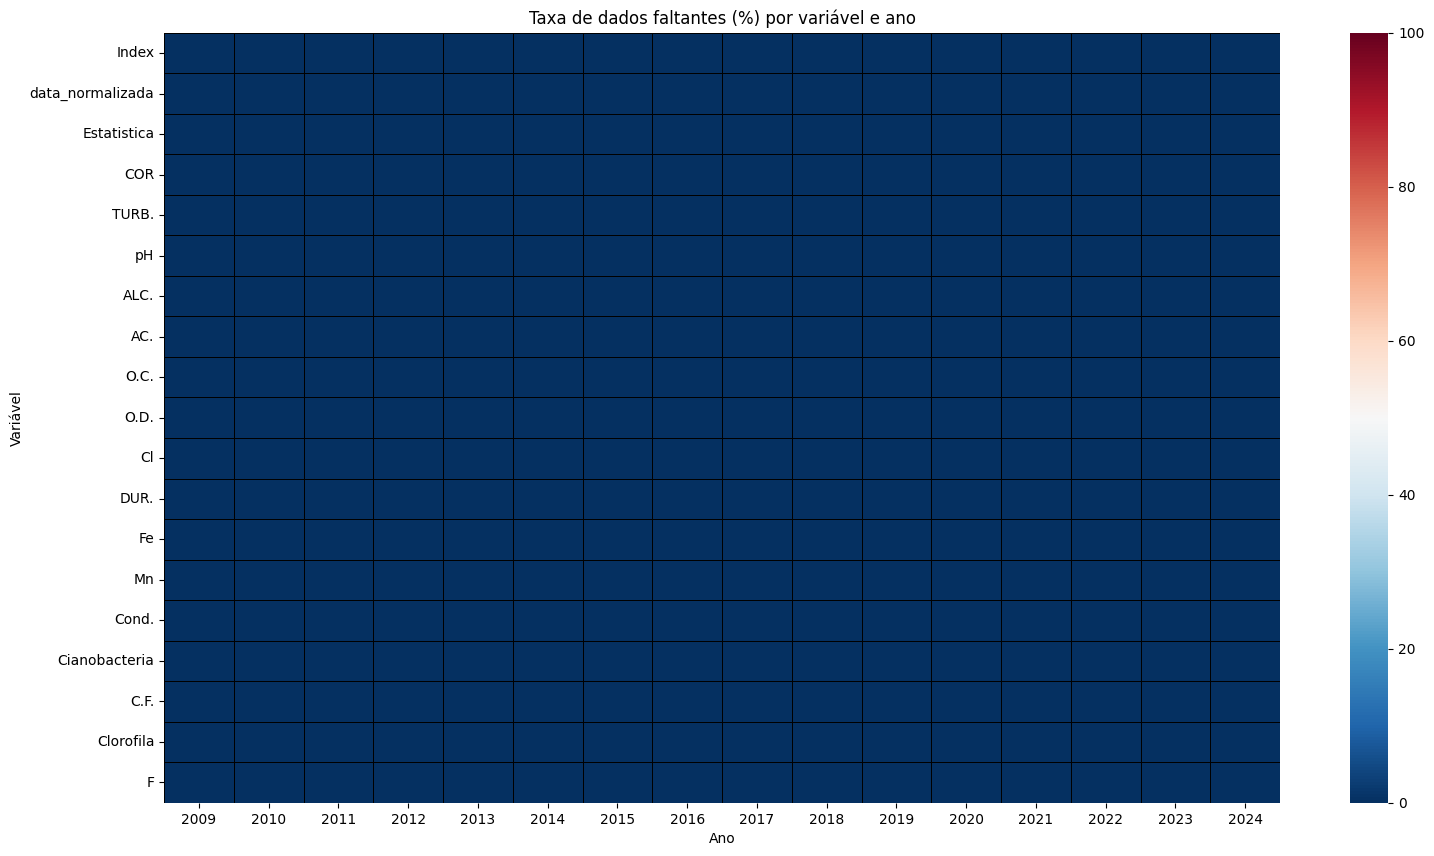

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\faltantes_mes_20260414_152439.png


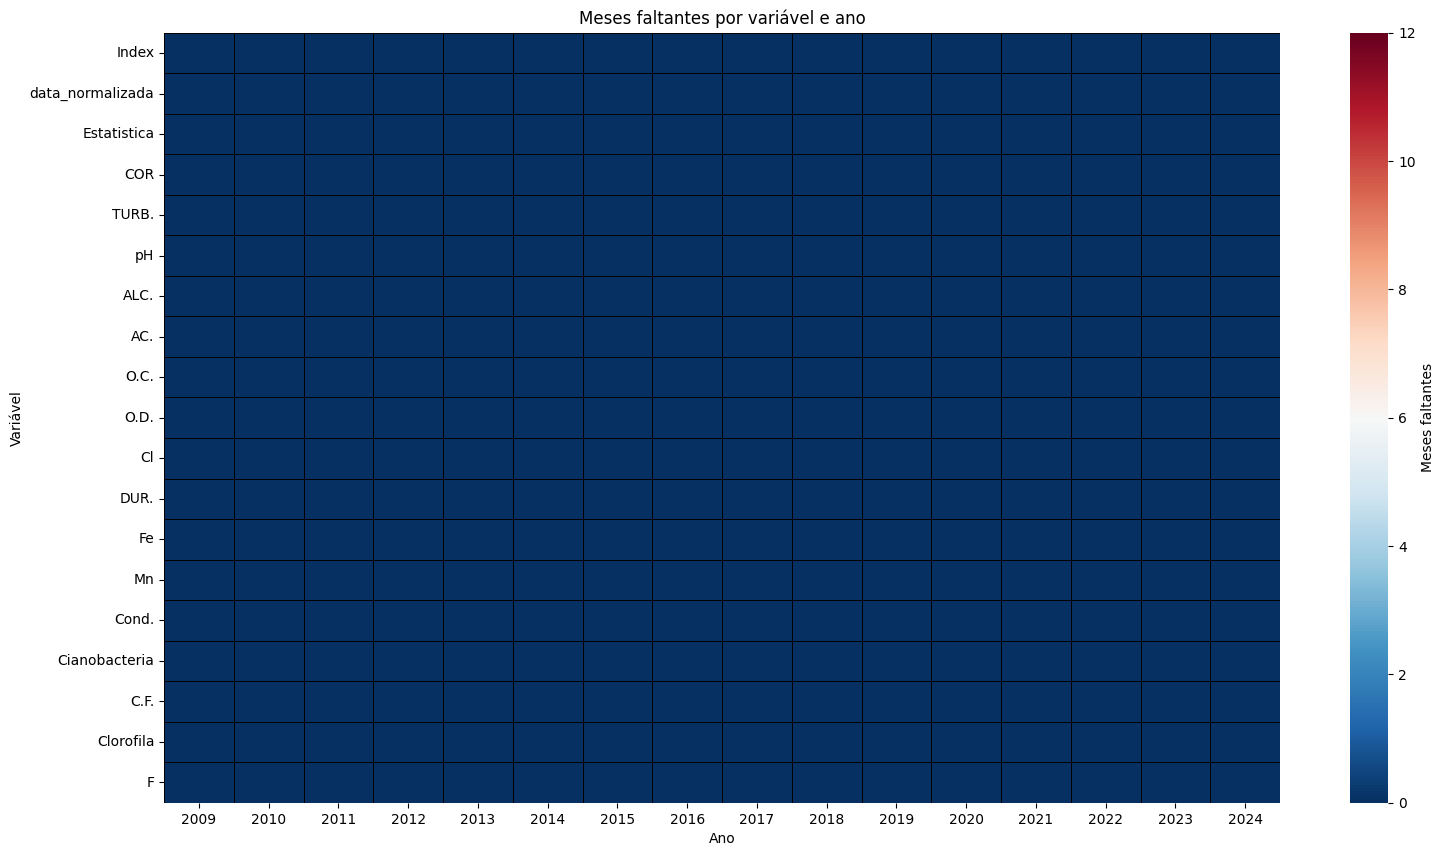

Visualização salva em: C:\_Master\Programacao\Guilherme-Betta\IC2\data\out\boxplot_tudo_20260414_152440.png


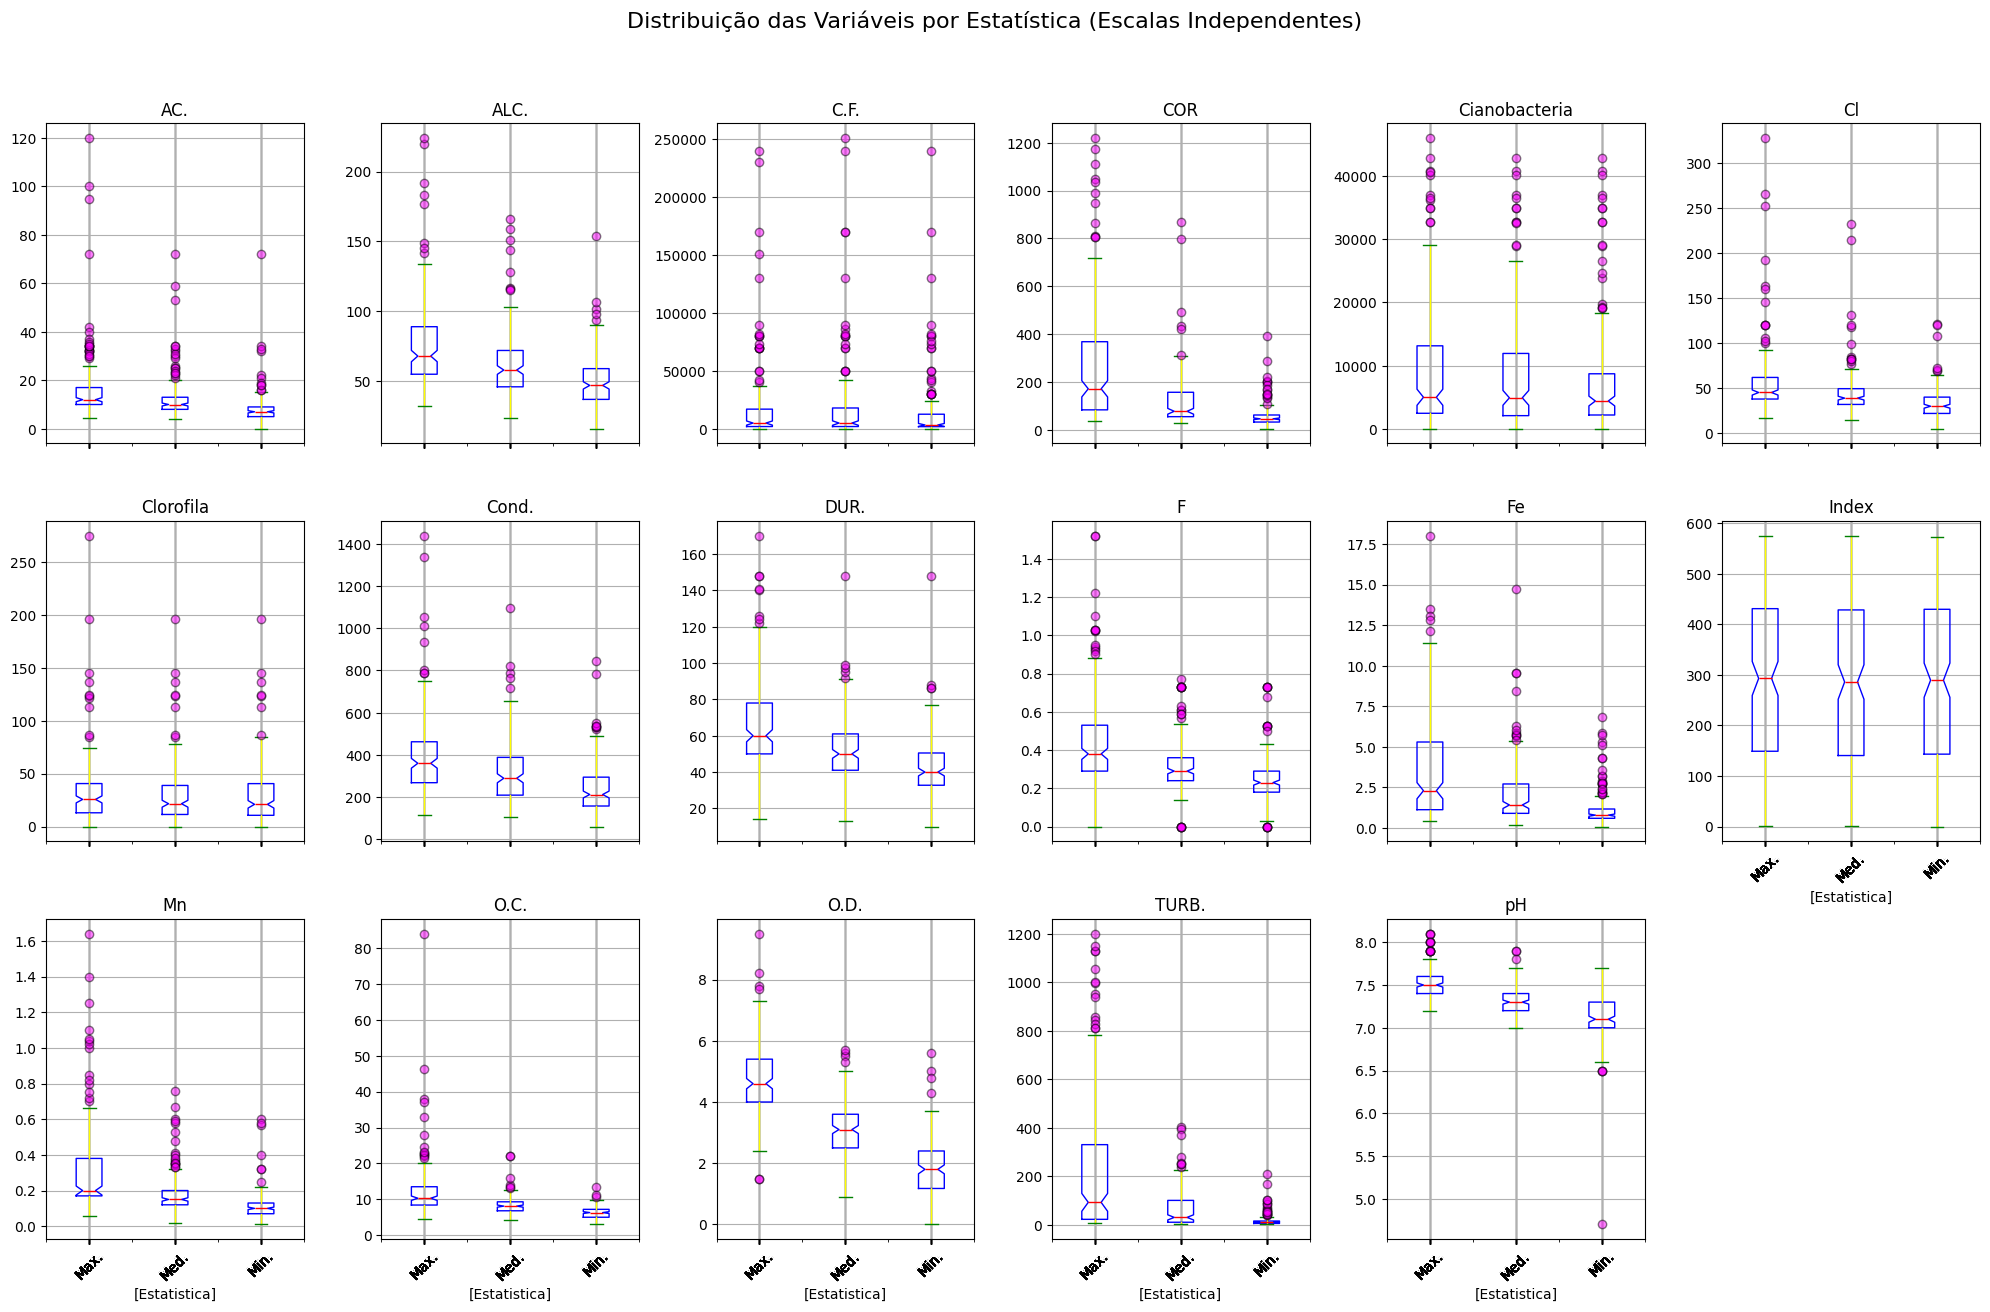

In [18]:
describe_lof = analise_descritiva(remocao_lof, metadados=metadados, variaveis=variaveis)
visualizacoes_todas(remocao_lof)